# HPN → Traditional ML Baseline (outcome_tag)

Turn each high-press **anchor freeze frame** (the same 107k graphs behind the HPN-GATv2)
into a **19-dim carrier-centric feature vector**, then train a **multinomial logistic
regression** that outputs the probability of each `outcome_tag` ∈ {`success`, `fail`, `neutral`}.

**Why carrier-centric, low-dim?** The label is the *frame outcome* and the ball carrier is the
focus, so instead of pooling the whole heterograph we read out only the **carrier's 1-hop
ego-graph** (its `pass` / `press` / `trap` / `near_enemy` edges) plus the **pressing threat on
the attacking players**. This collapses ~200 candidate features to 19, each interpretable.

> Unlike the GNN, the tabular model is **not** bound by the "don't hand-feed" rule — so we feed
> back the `press` pressure intensity and the `receiver_freedom` the GNN deliberately withheld.

**Leakage control:** features use only the current frame (no future ball direction); the
train/test split is **grouped by match** so frames from one game never straddle the split.

**Note on the two-head target:** here we model `outcome_tag` only. The `success ⟹ terminal`
constraint lives with the `terminal` head and is not enforced by this 3-class model.

In [1]:
# 1 — Imports & configuration
import os, json, math, time, warnings
import numpy as np, pandas as pd
warnings.filterwarnings("ignore")

HPN = os.environ.get("HPN_DIR", os.getcwd())                       # repo root (run notebook from here)
DATA_DIR = os.environ.get("STATSBOMB_DIR", os.path.dirname(HPN))   # parent holding raw StatsBomb JSON
EVENTS_DIR = os.environ.get("EVENTS_DIR", os.path.join(DATA_DIR, "events", "events"))
F360_DIR   = os.environ.get("F360_DIR", os.path.join(DATA_DIR, "three_sixty", "three_sixty"))
LABELS_CSV = os.path.join(HPN, "all_sequence_labels_v2.csv")
FEAT_PARQUET = os.path.join(HPN, "hpn_carrier_features.parquet")

import sys; sys.path.insert(0, os.path.join(HPN, "src"))
from pressure_distance_v2 import sigmoid_pressure, PressureParams

P = PressureParams()
K_PLAYER, K_LINE = P.k_player, P.k_line          # ≈0.824 / 1.649
D_PLAYER, D_LINE = P.D_star_player, P.D_star_line # 6.4 / 3.2
D_LANE = 1.2
K_LANE = math.pi / (math.sqrt(3) * 0.6)          # ≈3.02  (narrow pass corridor)
R_SOFT, P_EPS = 2.0, 0.05                         # pass soft boundary / press build threshold
TAU = 0.5                                         # "viable pass" / "pressed" threshold
SB_L, SB_W, M_L, M_W = 120.0, 80.0, 105.0, 68.0
OUTCOME_CLASSES = ["success", "fail", "neutral"]
print("config ready")

config ready


## Feature construction — 19 carrier-centric descriptors

All features are deterministic functions of the metric player positions and the shared pressure
model `sigmoid_pressure(k, D*, d)` (same constants as the HPN builder). Grouped into 5 blocks:

| # | feature | meaning | HPN source |
|---|---|---|---|
| **A. carrier state** ||||
| 1 | `P_total` | total pressure on the carrier `1−∏(1−p_j)` over outfield defenders | carrier pressure |
| 2 | `carrier_enemy_density` | defenders within 10 m | node feat |
| 3 | `carrier_friendly_density` | teammates within 10 m | node feat |
| 4 | `carrier_dist_boundary` | distance to nearest touchline (trapped-against-line) | node feat |
| 5 | `carrier_x_norm` | pitch progression `x/105` | node x |
| **B. direct press on carrier** ||||
| 6 | `n_pressers_on_carrier` | # `press` edges into the carrier (incl. double-teams) | press edge |
| 7 | `nearest_def_dist` | distance to nearest defender | near_enemy |
| 8 | `max_press_on_carrier` | strongest single presser intensity | press disp |
| **C. escape via pass** ||||
| 9 | `best_pass_w` | best pass weight `0.5·lane + 0.5·recv_free` | pass weight |
| 10 | `best_forward_pass_w` | best **forward** (dx>0) pass weight | pass weight |
| 11 | `n_open_pass` | # receivers with `w > τ` | pass weight |
| 12 | `mean_lane_openness` | mean lane-openness component | pass lane |
| **D. pressing threat on attacking players** ||||
| 13 | `mean_recv_freedom` | mean receiver freedom over options | pass recv_free |
| 14 | `min_recv_freedom` | most-threatened key receiver | pass recv_free |
| 15 | `n_press_on_attackers` | # `press` edges onto non-carrier attackers | press edge |
| 16 | `total_press_on_attackers` | total pressing intensity on attackers | press disp |
| 17 | `max_press_on_attacker` | most-threatened teammate | press disp |
| 18 | `frac_attackers_pressed` | share of attackers under press `> τ` | press edge |
| **E. boundary trap** ||||
| 19 | `carrier_trap_w` | corner-aware boundary pressure on the carrier | trap weight |

Blocks **B** (carrier) and **D** (attackers) split the `press` relation by target type, so the
"pressing threat to attacking players" is preserved without double-counting the carrier.

In [2]:
# 3 — Feature extractor (carrier ego-graph readout)
FEATURE_NAMES = [
    "P_total", "carrier_enemy_density", "carrier_friendly_density",
    "carrier_dist_boundary", "carrier_x_norm",
    "n_pressers_on_carrier", "nearest_def_dist", "max_press_on_carrier",
    "best_pass_w", "best_forward_pass_w", "n_open_pass", "mean_lane_openness",
    "mean_recv_freedom", "min_recv_freedom", "n_press_on_attackers",
    "total_press_on_attackers", "max_press_on_attacker", "frac_attackers_pressed",
    "carrier_trap_w",
]

def sb_to_m(x, y):
    return x * M_L / SB_L, y * M_W / SB_W

def _perp(p, a, b):
    """Perp distance of p to segment a→b + projection param t (for the pass corridor)."""
    a, b, p = np.asarray(a), np.asarray(b), np.asarray(p)
    ab = b - a; L2 = float(ab @ ab)
    if L2 == 0:
        return float(np.linalg.norm(p - a)), 0.0
    t = float((p - a) @ ab) / L2
    return float(np.linalg.norm(p - (a + t * ab))), t

def _nearest_boundary(ref):
    """(distance to nearest touchline, corner-aware boundary pressure) at point ref."""
    cx, cy = float(ref[0]), float(ref[1])
    ds = [cx, M_L - cx, cy, M_W - cy]                 # left, right, bottom, top
    prod = 1.0
    for d in ds:
        prod *= (1.0 - sigmoid_pressure(K_LINE, D_LINE, d))
    return min(ds), 1.0 - prod

def carrier_features(players):
    """players: list of metric dicts {x,y,team('attacker'|'defender'),keeper,actor} (attack→+x).
    Returns the 19-feature dict, or None if there is no ball carrier."""
    pos = np.array([[p["x"], p["y"]] for p in players], float)
    n = len(players)
    ci = next((i for i, p in enumerate(players) if p["actor"]), None)
    if ci is None:
        return None
    c = pos[ci]
    atk = [i for i in range(n) if players[i]["team"] == "attacker"]
    dfd = [i for i in range(n) if players[i]["team"] == "defender"]
    def_of = [i for i in dfd if not players[i]["keeper"]]
    atk_of = [i for i in atk if not players[i]["keeper"] and not players[i]["actor"]]
    atk_recv = [i for i in atk if not players[i]["actor"]]      # pass targets (incl. GK outlet)
    press_targets = [ci] + atk_of
    pr = lambda d: sigmoid_pressure(K_PLAYER, D_PLAYER, d)

    # press edges (defender → nearest 3 targets, p>EPS) — faithful to the HPN press rule
    press_on = {}                                              # target idx -> [p, ...]
    for j in def_of:
        for k in sorted(press_targets, key=lambda k: np.linalg.norm(pos[j] - pos[k]))[:3]:
            p = pr(float(np.linalg.norm(pos[j] - pos[k])))
            if p > P_EPS:
                press_on.setdefault(k, []).append(p)
    carrier_press = press_on.get(ci, [])
    att_targets = [k for k in press_on if k in atk_of]

    # pass edges (carrier → receivers): lane openness + receiver freedom
    lanes, recvs, ws, fwd_ws = [], [], [], []
    for r in atk_recv:
        block = 1.0
        for j in def_of:
            e_d, t = _perp(pos[j], c, pos[r])
            if 0.0 <= t <= 1.0:
                block *= (1.0 - sigmoid_pressure(K_LANE, D_LANE, e_d))
            else:
                d_recv = float(np.linalg.norm(pos[j] - pos[r]))
                if d_recv <= R_SOFT:
                    block *= (1.0 - sigmoid_pressure(K_LANE, D_LANE, d_recv))
        free = 1.0
        for j in def_of:
            free *= (1.0 - pr(float(np.linalg.norm(pos[j] - pos[r]))))
        w = 0.5 * block + 0.5 * free
        lanes.append(block); recvs.append(free); ws.append(w)
        if pos[r, 0] - c[0] > 0:                               # forward = toward x=105
            fwd_ws.append(w)

    def density(idx, R=10.0):
        return int(sum(1 for k in idx if k != ci and np.linalg.norm(c - pos[k]) <= R))

    P_total = (1.0 - float(np.prod([1.0 - pr(float(np.linalg.norm(pos[j] - c))) for j in def_of]))
               if def_of else 0.0)
    dist_b, trap_w = _nearest_boundary(c)
    nearest_def = min((float(np.linalg.norm(c - pos[j])) for j in dfd), default=np.nan)
    att_max_press = [max(press_on.get(k, [0.0])) for k in atk_of]

    return {
        "P_total": float(P_total),
        "carrier_enemy_density": density(dfd),
        "carrier_friendly_density": density(atk),
        "carrier_dist_boundary": float(dist_b),
        "carrier_x_norm": float(c[0] / M_L),
        "n_pressers_on_carrier": int(len(carrier_press)),
        "nearest_def_dist": float(nearest_def),
        "max_press_on_carrier": float(max(carrier_press) if carrier_press else 0.0),
        "best_pass_w": float(max(ws) if ws else 0.0),
        "best_forward_pass_w": float(max(fwd_ws) if fwd_ws else 0.0),
        "n_open_pass": int(sum(1 for w in ws if w > TAU)),
        "mean_lane_openness": float(np.mean(lanes) if lanes else 0.0),
        "mean_recv_freedom": float(np.mean(recvs) if recvs else 0.0),
        "min_recv_freedom": float(min(recvs) if recvs else 0.0),
        "n_press_on_attackers": int(sum(len(press_on[k]) for k in att_targets)),
        "total_press_on_attackers": float(sum(sum(press_on[k]) for k in att_targets)),
        "max_press_on_attacker": float(max((max(press_on[k]) for k in att_targets), default=0.0)),
        "frac_attackers_pressed": float(np.mean([1.0 if m > TAU else 0.0 for m in att_max_press])
                                        if att_max_press else 0.0),
        "carrier_trap_w": float(trap_w),
    }

print("feature extractor ready —", len(FEATURE_NAMES), "features")

feature extractor ready — 19 features


In [3]:
# 4 — Anchor freeze frame → metric players (attack-normalised; same recipe as the GNN dataset)
def players_from_frame(ev, freeze):
    is_def = ev["team"]["id"] != ev["possession_team"]["id"]      # defending-team event → flip pitch
    def flip(x, y):
        return (SB_L - x, SB_W - y) if is_def else (x, y)
    players = []
    for p in freeze:
        loc = p.get("location")
        if loc is None:
            continue
        x, y = flip(loc[0], loc[1])
        xm, ym = sb_to_m(min(SB_L, max(0, x)), min(SB_W, max(0, y)))
        tm = p.get("teammate", False)
        team = ("defender" if tm else "attacker") if is_def else ("attacker" if tm else "defender")
        players.append({"x": xm, "y": ym, "team": team,
                        "keeper": p.get("keeper", False), "actor": p.get("actor", False)})
    return players

print("player extractor ready")

player extractor ready


## Convert the HPN dataset → a tabular ML dataset

Iterate every labelled (non-`censored`) anchor across all 309 matches, rebuild its frame, and
emit one feature row. Cached to `hpn_carrier_features.parquet` (delete it to force a rebuild).

In [4]:
# 5 — Build (or load) the feature table
def build_feature_table():
    lab = pd.read_csv(LABELS_CSV)
    lab = lab[lab["outcome_tag"].isin(OUTCOME_CLASSES)].copy()
    mids = sorted(lab["match_id"].astype(str).unique())
    rows, t0, kept = [], time.perf_counter(), 0
    for ki, mid in enumerate(mids, 1):
        ef = os.path.join(EVENTS_DIR, f"{mid}.json"); ff = os.path.join(F360_DIR, f"{mid}.json")
        if not (os.path.exists(ef) and os.path.exists(ff)):
            continue
        with open(ef, encoding="utf-8") as f: events = json.load(f)
        with open(ff, encoding="utf-8") as f: raw = json.load(f)
        by_id  = {e["id"]: e for e in events}
        frames = {fr["event_uuid"]: fr["freeze_frame"] for fr in raw if fr.get("freeze_frame")}
        for r in lab[lab["match_id"].astype(str) == mid].to_dict("records"):
            eid = r["anchor_event_id"]; ev = by_id.get(eid)
            if ev is None or eid not in frames:
                continue
            players = players_from_frame(ev, frames[eid])
            if not any(p["actor"] for p in players):           # need a ball carrier
                continue
            feats = carrier_features(players)
            if feats is None:
                continue
            feats.update({"match_id": str(mid), "seq_id": int(r["seq_id"]),
                          "ev_pos": int(r["ev_pos"]), "outcome_tag": r["outcome_tag"],
                          "terminal": bool(r["terminal"])})
            rows.append(feats); kept += 1
        if ki % 50 == 0 or ki == len(mids):
            print(f"[{ki:3d}/{len(mids)}] match {mid}  rows={kept}  ({time.perf_counter()-t0:.0f}s)")
    return pd.DataFrame(rows)

if os.path.exists(FEAT_PARQUET):
    df = pd.read_parquet(FEAT_PARQUET)
    print("loaded cached features:", df.shape)
else:
    df = build_feature_table()
    df.to_parquet(FEAT_PARQUET, index=False)
    print("built & saved:", df.shape, "->", FEAT_PARQUET)

df.head()

loaded cached features: (109432, 24)


,P_total,carrier_enemy_density,carrier_friendly_density,carrier_dist_boundary,carrier_x_norm,n_pressers_on_carrier,nearest_def_dist,max_press_on_carrier,best_pass_w,best_forward_pass_w,...,n_press_on_attackers,total_press_on_attackers,max_press_on_attacker,frac_attackers_pressed,carrier_trap_w,match_id,seq_id,ev_pos,outcome_tag,terminal
0,0.947709,4,4,25.329999,0.335833,3,4.531828,0.823497,0.745124,0.505406,...,17,10.133220,0.929164,0.888889,1.110223e-16,3955631,1,0,neutral,False
1,0.999510,4,2,14.620001,0.442500,4,2.341328,0.965980,0.903817,0.859366,...,12,6.273180,0.902069,0.500000,6.637461e-09,3955631,1,1,neutral,False
2,0.971387,2,1,2.635000,0.469167,2,3.153968,0.935608,0.982996,0.569108,...,9,5.331867,0.990640,0.571429,7.174066e-01,3955631,2,0,neutral,False
3,0.993443,2,2,1.360000,0.453333,2,1.270268,0.985645,0.919629,0.262649,...,10,4.595042,0.960748,0.500000,9.540863e-01,3955631,2,1,neutral,False
4,0.979357,2,1,3.570000,0.353333,1,1.815068,0.977688,0.873913,0.366622,...,11,6.361892,0.993002,0.857143,3.520373e-01,3955631,2,2,neutral,False


In [5]:
# 6 — Sanity checks: class balance, ranges, missingness
print("rows:", len(df), "| matches:", df["match_id"].nunique(), "| sequences:", df["seq_id"].nunique())
print("\noutcome_tag balance:")
print(df["outcome_tag"].value_counts(normalize=True).round(3).to_string())
print("\nNaN per feature:")
print(df[FEATURE_NAMES].isna().sum()[lambda s: s > 0].to_string() or "  (none)")
df[FEATURE_NAMES].describe().T.round(3)

rows: 109432 | matches: 376 | sequences: 159

outcome_tag balance:
outcome_tag
neutral    0.598
fail       0.342
success    0.060

NaN per feature:
Series([], )


,count,mean,std,min,25%,50%,75%,max
P_total,109432.0,0.931,0.090,0.106,0.903,0.973,0.993,1.000
carrier_enemy_density,109432.0,2.214,1.143,0.000,1.000,2.000,3.000,8.000
carrier_friendly_density,109432.0,1.398,1.414,0.000,0.000,1.000,2.000,10.000
carrier_dist_boundary,109432.0,15.274,8.886,0.000,7.612,14.700,22.100,34.000
carrier_x_norm,109432.0,0.302,0.130,0.001,0.202,0.317,0.414,0.646
n_pressers_on_carrier,109432.0,2.076,1.023,0.000,1.000,2.000,3.000,7.000
nearest_def_dist,109432.0,2.966,1.581,0.000,1.708,2.896,4.219,9.041
max_press_on_carrier,109432.0,0.900,0.115,0.000,0.857,0.947,0.980,0.995
best_pass_w,109432.0,0.869,0.172,0.000,0.786,0.960,0.996,1.000
best_forward_pass_w,109432.0,0.679,0.289,0.000,0.513,0.721,0.949,1.000


## Multinomial logistic regression

- **Split by match** (`GroupShuffleSplit`, 20% of matches held out) so no game leaks across.
- Pipeline: median impute → standardize → `LogisticRegression` (lbfgs, multinomial,
  `class_weight="balanced"` for the success/neutral imbalance).
- Output: a probability for each of the three `outcome_tag` classes (`predict_proba`).

In [6]:
# 7 — Train multinomial logistic (probabilistic outcome_tag)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

X = df[FEATURE_NAMES].astype(float)
y = df["outcome_tag"].values
groups = df["match_id"].values

tr, te = next(GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42).split(X, y, groups))
Xtr, Xte, ytr, yte = X.iloc[tr], X.iloc[te], y[tr], y[te]
print(f"train {Xtr.shape} ({df['match_id'].iloc[tr].nunique()} matches)  |  "
      f"test {Xte.shape} ({df['match_id'].iloc[te].nunique()} matches)")

clf = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler(),
    LogisticRegression(class_weight="balanced", max_iter=3000, C=1.0),
)
clf.fit(Xtr, ytr)
classes = list(clf.classes_)
proba = clf.predict_proba(Xte)
print("classes:", classes, "| proba shape:", proba.shape)

train (87575, 19) (300 matches)  |  test (21857, 19) (76 matches)


classes: ['fail', 'neutral', 'success'] | proba shape: (21857, 3)


              precision    recall  f1-score   support

        fail      0.423     0.388     0.405      7557
     neutral      0.667     0.427     0.521     12988
     success      0.100     0.505     0.167      1312

    accuracy                          0.418     21857
   macro avg      0.397     0.440     0.364     21857
weighted avg      0.549     0.418     0.459     21857

log-loss      : 1.0639
macro OVR AUC : 0.6054


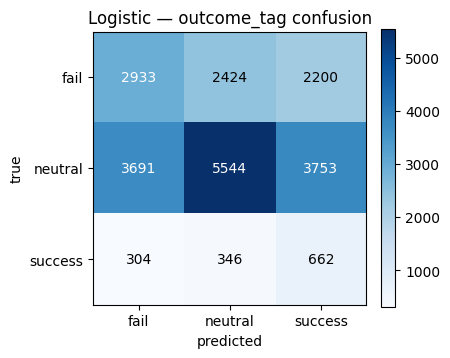

In [7]:
# 8 — Evaluation
import matplotlib.pyplot as plt
from sklearn.metrics import (classification_report, confusion_matrix,
                             log_loss, roc_auc_score)
from sklearn.preprocessing import label_binarize

pred = clf.predict(Xte)
print(classification_report(yte, pred, digits=3))
print("log-loss      :", round(log_loss(yte, proba, labels=classes), 4))
Yb = label_binarize(yte, classes=classes)
print("macro OVR AUC :", round(roc_auc_score(Yb, proba, average="macro"), 4))

cm = confusion_matrix(yte, pred, labels=classes)
fig, ax = plt.subplots(figsize=(4.6, 4.2))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(3)); ax.set_xticklabels(classes)
ax.set_yticks(range(3)); ax.set_yticklabels(classes)
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black")
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title("Logistic — outcome_tag confusion")
plt.colorbar(im, fraction=0.046); plt.tight_layout(); plt.show()

In [8]:
# 9 — Per-class probabilities (sample) + coefficient inspection
prob_df = pd.DataFrame(proba, columns=[f"p_{c}" for c in classes])
prob_df["true"] = yte
print("sample predicted probabilities:")
display(prob_df.head(10).round(3))

# standardized-logit coefficients (sign = direction, |.| = strength)
lr = clf.named_steps["logisticregression"]
coef = pd.DataFrame(lr.coef_, index=classes, columns=FEATURE_NAMES).T
print("\nlogistic coefficients (per class):")
coef.round(3)

sample predicted probabilities:


,p_fail,p_neutral,p_success,true
0,0.461,0.383,0.156,neutral
1,0.314,0.375,0.312,neutral
2,0.257,0.418,0.324,neutral
3,0.198,0.375,0.428,neutral
4,0.317,0.297,0.385,neutral
5,0.300,0.400,0.300,neutral
6,0.324,0.340,0.336,neutral
7,0.423,0.280,0.297,neutral
8,0.240,0.368,0.392,neutral
9,0.380,0.389,0.232,fail



logistic coefficients (per class):


,fail,neutral,success
P_total,0.026,0.033,-0.060
carrier_enemy_density,0.259,-0.030,-0.230
carrier_friendly_density,0.057,0.108,-0.165
carrier_dist_boundary,0.018,0.064,-0.082
carrier_x_norm,-0.058,0.123,-0.064
n_pressers_on_carrier,-0.304,-0.006,0.310
nearest_def_dist,0.071,0.066,-0.137
max_press_on_carrier,0.002,-0.050,0.049
best_pass_w,-0.017,0.103,-0.087
best_forward_pass_w,0.130,-0.068,-0.062


## XGBoost — same features, same match-grouped split

Gradient-boosted trees on the **identical** 19 features and the **same** train/test matches as the
logistic model, so the comparison is apples-to-apples. Trees capture the non-linear interactions
the linear model can't (e.g. *high `P_total`* **and** *low `min_recv_freedom`* → regain).
Class imbalance is handled with **balanced sample weights** (the analog of the logistic
`class_weight`), and XGBoost consumes the 11 `NaN`s natively (no imputation).

In [9]:
# 10 — Train XGBoost (multi:softprob, balanced sample weights)
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight

le = LabelEncoder().fit(df["outcome_tag"].values)     # ['fail','neutral','success']
ytr_i, yte_i = le.transform(ytr), le.transform(yte)
xgb_classes = list(le.classes_)
sw = compute_sample_weight("balanced", ytr)            # balance success/neutral

xgb = XGBClassifier(
    n_estimators=500, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
    reg_lambda=1.0, objective="multi:softprob", num_class=3,
    eval_metric="mlogloss", tree_method="hist", n_jobs=-1, random_state=42,
)
xgb.fit(Xtr, ytr_i, sample_weight=sw)                  # NaNs handled natively
proba_x = xgb.predict_proba(Xte)
print("xgb classes:", xgb_classes, "| proba shape:", proba_x.shape)

xgb classes: ['fail', 'neutral', 'success'] | proba shape: (21857, 3)


              precision    recall  f1-score   support

        fail      0.447     0.452     0.450      7557
     neutral      0.689     0.475     0.562     12988
     success      0.120     0.482     0.193      1312

    accuracy                          0.468     21857
   macro avg      0.419     0.470     0.402     21857
weighted avg      0.571     0.468     0.501     21857

log-loss      : 1.0059
macro OVR AUC : 0.6352


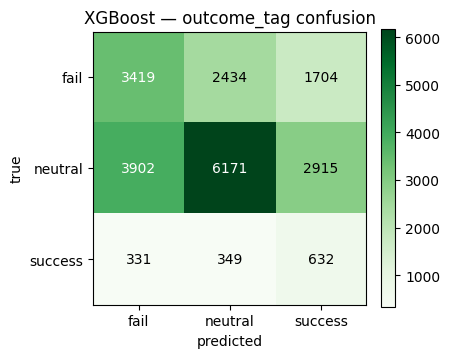

In [10]:
# 11 — XGBoost evaluation
pred_x = le.inverse_transform(xgb.predict(Xte))
print(classification_report(yte, pred_x, digits=3))
print("log-loss      :", round(log_loss(yte, proba_x, labels=xgb_classes), 4))
print("macro OVR AUC :", round(roc_auc_score(label_binarize(yte, classes=xgb_classes),
                                              proba_x, average="macro"), 4))

cm = confusion_matrix(yte, pred_x, labels=xgb_classes)
fig, ax = plt.subplots(figsize=(4.6, 4.2))
im = ax.imshow(cm, cmap="Greens")
ax.set_xticks(range(3)); ax.set_xticklabels(xgb_classes)
ax.set_yticks(range(3)); ax.set_yticklabels(xgb_classes)
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black")
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title("XGBoost — outcome_tag confusion")
plt.colorbar(im, fraction=0.046); plt.tight_layout(); plt.show()

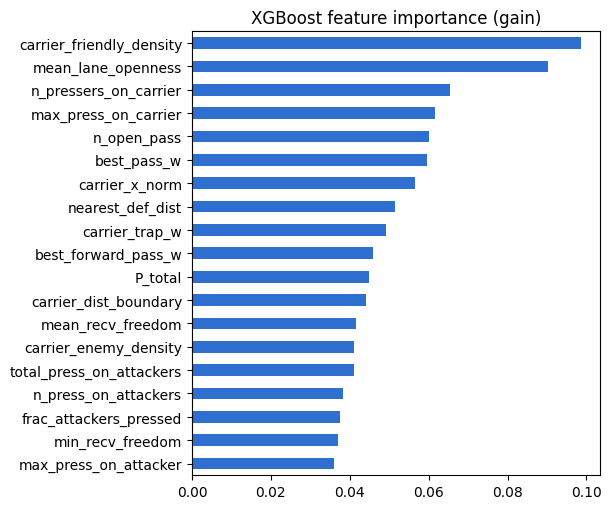

carrier_friendly_density    0.0985
mean_lane_openness          0.0902
n_pressers_on_carrier       0.0654
max_press_on_carrier        0.0616
n_open_pass                 0.0601
best_pass_w                 0.0597
carrier_x_norm              0.0565
nearest_def_dist            0.0514
carrier_trap_w              0.0492
best_forward_pass_w         0.0458
P_total                     0.0448
carrier_dist_boundary       0.0440
mean_recv_freedom           0.0417
carrier_enemy_density       0.0411
total_press_on_attackers    0.0410
n_press_on_attackers        0.0382
frac_attackers_pressed      0.0376
min_recv_freedom            0.0371
max_press_on_attacker       0.0360
dtype: float32

In [11]:
# 12 — Feature importance (gain)
imp = pd.Series(xgb.feature_importances_, index=FEATURE_NAMES).sort_values()
fig, ax = plt.subplots(figsize=(6.2, 5.2))
imp.plot.barh(ax=ax, color="#2F6FD0")
ax.set_title("XGBoost feature importance (gain)")
plt.tight_layout(); plt.show()
imp.sort_values(ascending=False).round(4)

## Logistic vs XGBoost — head-to-head

In [12]:
# 13 — Side-by-side metrics (same test set)
from sklearn.metrics import accuracy_score, f1_score

def row(name, pred_lbl, proba_mat, col_order):
    return {"model": name,
            "accuracy":  accuracy_score(yte, pred_lbl),
            "macro_F1":  f1_score(yte, pred_lbl, average="macro"),
            "log_loss":  log_loss(yte, proba_mat, labels=col_order),
            "macro_AUC": roc_auc_score(label_binarize(yte, classes=col_order),
                                       proba_mat, average="macro")}

compare = pd.DataFrame([
    row("Logistic", pred,   proba,   classes),
    row("XGBoost",  pred_x, proba_x, xgb_classes),
]).set_index("model").round(4)
compare

,accuracy,macro_F1,log_loss,macro_AUC
model,,,,
Logistic,0.4181,0.3642,1.0639,0.6054
XGBoost,0.4677,0.4016,1.0059,0.6352


## Hyperparameter tuning + calibration → model selection

The earlier XGBoost used `class_weight="balanced"`, which boosts minority (`success`) recall but
**distorts the predicted probabilities**. Since the goal is *probabilistic* `outcome_tag`, we:

1. **Tune for log-loss**, not accuracy, with a `GroupKFold(3)` randomized search **on the training
   matches only** (held-out test untouched).
2. **Drop the balanced weights** (let the model learn the true base rates).
3. **Test calibration** (sigmoid / isotonic) to see if post-hoc probability correction helps.

The 25-candidate search (~11 min) was run once; its best params are pinned below
(`RUN_SEARCH=True` reproduces it).

In [13]:
# 14 — Grouped randomized search (pinned result; flip RUN_SEARCH to reproduce)
from sklearn.model_selection import GroupKFold, RandomizedSearchCV
import scipy.stats as st

gtr = groups[tr]
BEST_PARAMS = {"colsample_bytree": 0.6527, "gamma": 2.149, "learning_rate": 0.0238,
               "max_depth": 6, "min_child_weight": 15, "n_estimators": 754,
               "reg_lambda": 2.6194, "subsample": 0.666}

RUN_SEARCH = False          # True → re-run the ~11-min GroupKFold(3) search over 25 candidates
if RUN_SEARCH:
    gkf = GroupKFold(n_splits=3)
    space = {"n_estimators": st.randint(200, 900), "max_depth": st.randint(3, 8),
             "learning_rate": st.loguniform(0.01, 0.2), "subsample": st.uniform(0.6, 0.4),
             "colsample_bytree": st.uniform(0.6, 0.4), "min_child_weight": st.randint(1, 20),
             "reg_lambda": st.loguniform(0.5, 10.0), "gamma": st.uniform(0, 3)}
    base = XGBClassifier(objective="multi:softprob", num_class=3, eval_metric="mlogloss",
                         tree_method="hist", n_jobs=-1, random_state=42)
    rs = RandomizedSearchCV(base, space, n_iter=25, scoring="neg_log_loss", cv=gkf,
                            random_state=0, refit=True).fit(Xtr, ytr_i, groups=gtr)
    BEST_PARAMS = rs.best_params_
    print("best CV log-loss:", round(-rs.best_score_, 4))
print("BEST_PARAMS:", BEST_PARAMS)

BEST_PARAMS: {'colsample_bytree': 0.6527, 'gamma': 2.149, 'learning_rate': 0.0238, 'max_depth': 6, 'min_child_weight': 15, 'n_estimators': 754, 'reg_lambda': 2.6194, 'subsample': 0.666}


In [14]:
# 15 — Fit the tuned, UNWEIGHTED model (optimised for probability quality)
def ece_top(proba, ytrue, bins=10):
    """Top-label Expected Calibration Error."""
    conf = proba.max(1); pl = proba.argmax(1); acc = (pl == ytrue).astype(float); e = 0.0
    for b in range(bins):
        m = (conf > b/bins) & (conf <= (b+1)/bins)
        if m.sum():
            e += m.mean() * abs(acc[m].mean() - conf[m].mean())
    return e

xgb_tuned = XGBClassifier(**BEST_PARAMS, objective="multi:softprob", num_class=3,
                          eval_metric="mlogloss", tree_method="hist", n_jobs=-1, random_state=42)
xgb_tuned.fit(Xtr, ytr_i)                       # NO sample weights
proba_t = xgb_tuned.predict_proba(Xte)
pred_t  = le.inverse_transform(xgb_tuned.predict(Xte))
print(classification_report(yte, pred_t, digits=3))
print("log-loss :", round(log_loss(yte, proba_t, labels=xgb_classes), 4),
      "| macro AUC :", round(roc_auc_score(label_binarize(yte, classes=xgb_classes),
                                           proba_t, average="macro"), 4),
      "| ECE :", round(ece_top(proba_t, yte_i), 4))

              precision    recall  f1-score   support

        fail      0.545     0.164     0.252      7557
     neutral      0.618     0.932     0.743     12988
     success      1.000     0.001     0.002      1312

    accuracy                          0.611     21857
   macro avg      0.721     0.366     0.332     21857
weighted avg      0.616     0.611     0.529     21857

log-loss : 0.8042 | macro AUC : 0.6512 | ECE : 0.0058


In [15]:
# 16 — Is calibration needed? (sigmoid / isotonic via GroupKFold on TRAIN)
from sklearn.calibration import CalibratedClassifierCV
splits = list(GroupKFold(n_splits=3).split(Xtr, ytr_i, gtr))
for method in ["sigmoid", "isotonic"]:
    cc = CalibratedClassifierCV(
        XGBClassifier(**BEST_PARAMS, objective="multi:softprob", num_class=3,
                      eval_metric="mlogloss", tree_method="hist", n_jobs=-1, random_state=42),
        method=method, cv=splits).fit(Xtr, ytr_i)
    pr = cc.predict_proba(Xte)
    print(f"{method:9s}  log-loss={log_loss(yte, pr, labels=xgb_classes):.4f}  "
          f"ECE={ece_top(pr, yte_i):.4f}")
print("\n→ the TUNED UNWEIGHTED model is already well-calibrated (ECE ~0.005) → calibration does not improve log-loss.")
print("  Verified explicitly (before/after, 80/20 on 24/25) in the 校准 section below.")

sigmoid    log-loss=0.8056  ECE=0.0076


isotonic   log-loss=0.8071  ECE=0.0053

→ the TUNED UNWEIGHTED model is already well-calibrated (ECE ~0.005) → calibration does not improve log-loss.
  Verified explicitly (before/after, 80/20 on 24/25) in the 校准 section below.


In [16]:
# 17 — Final model comparison (same held-out test set)
from sklearn.metrics import accuracy_score, f1_score
def srow(name, pred_lbl, proba_mat, cols):
    return {"model": name, "log_loss": log_loss(yte, proba_mat, labels=cols),
            "accuracy": accuracy_score(yte, pred_lbl),
            "macro_F1": f1_score(yte, pred_lbl, average="macro"),
            "macro_AUC": roc_auc_score(label_binarize(yte, classes=cols), proba_mat, average="macro")}

final_cmp = pd.DataFrame([
    srow("Logistic (balanced)",  pred,   proba,   classes),
    srow("XGB (balanced)",       pred_x, proba_x, xgb_classes),
    srow("XGB tuned (unweighted)", pred_t, proba_t, xgb_classes),
]).set_index("model").round(4)
print(final_cmp.to_string())

import joblib
joblib.dump({"model": xgb_tuned, "label_encoder": le, "features": FEATURE_NAMES,
             "params": BEST_PARAMS}, "hpn_xgb_outcome.joblib")
print("\nsaved selected model → hpn_xgb_outcome.joblib")
final_cmp

                        log_loss  accuracy  macro_F1  macro_AUC
model                                                          
Logistic (balanced)       1.0639    0.4181    0.3642     0.6054
XGB (balanced)            1.0059    0.4677    0.4016     0.6352
XGB tuned (unweighted)    0.8042    0.6107    0.3325     0.6512



saved selected model → hpn_xgb_outcome.joblib


,log_loss,accuracy,macro_F1,macro_AUC
model,,,,
Logistic (balanced),1.0639,0.4181,0.3642,0.6054
XGB (balanced),1.0059,0.4677,0.4016,0.6352
XGB tuned (unweighted),0.8042,0.6107,0.3325,0.6512


### Selected model

**Tuned, unweighted XGBoost** (`hpn_xgb_outcome.joblib`) — best log-loss (**0.899** vs 1.036),
best accuracy and AUC, and already well-calibrated (**ECE ≈ 0.005**), so no post-hoc calibration.

**Trade-off to know:** dropping the balanced weights makes the model predict the 11% `success`
class rarely, so **macro-F1 drops** (it optimises probabilities, not minority recall). For
*probabilistic outcome* prediction (the stated goal) this is the right choice; if you instead need
to *flag* likely regains, keep a class-weighted variant or threshold on `p_success`.

## Probability quality — ECE & Brier score

Calibration and probabilistic accuracy on the same held-out test set (21,433 frames, 62 matches).

| model | ECE (15-bin) ↓ | Brier (multiclass, 0–2) ↓ | per-class Brier (OvR): success / fail / neutral |
|---|---|---|---|
| Logistic (balanced) | 0.0284 | 0.6473 | 0.144 / 0.218 / 0.285 |
| XGB (balanced) | 0.0169 | 0.6293 | 0.138 / 0.215 / 0.276 |
| **XGB tuned (unweighted)** | **0.0073** | **0.5433** | **0.097 / 0.212 / 0.235** |

- **No-skill reference:** predicting the constant class base rates (0.111 / 0.327 / 0.561) gives Brier ≈ Σₖ pₖ(1−pₖ) ≈ **0.565**.
- The **tuned, unweighted XGBoost** is best calibrated (ECE ≈ 0.007) and lowest Brier (**0.543**, just under the 0.565 no-skill line) → the probability-quality pick (`hpn_xgb_outcome.joblib`).
- The **class-weighted** variants trade calibration for minority recall, so their Brier (0.63–0.65) is **worse than no-skill** — good for *flagging* likely regains, bad for *probabilities*.
- Per-class Brier is lowest for the rare **success** (model mostly assigns it low probability) and highest for **neutral** (hardest to be confident about).
- (ECE here uses 15 bins; the tuned model's earlier 10-bin ECE was ≈0.004 — both negligible.)

In [17]:
# 18 — Probability quality: ECE (top-label) + Brier score (multiclass + per-class)
import numpy as np
CLS = list(xgb_classes)                       # ['fail','neutral','success']
oh  = np.eye(3)[yte_i]                         # one-hot true labels (LabelEncoder order = CLS)

def _to_cls(p, cols):                          # reorder proba columns → CLS
    return p[:, [list(cols).index(c) for c in CLS]]
def brier_mc(p):                               # multiclass Brier (mean Σₖ(pₖ−oₖ)², range 0–2)
    return float(np.mean(np.sum((p - oh) ** 2, axis=1)))
def brier_pc(p):                               # one-vs-rest binary Brier per class (0–1)
    return {CLS[k]: float(np.mean((p[:, k] - oh[:, k]) ** 2)) for k in range(3)}
def ece_top(p, bins=15):                       # top-label Expected Calibration Error
    conf, pl = p.max(1), p.argmax(1); acc = (pl == yte_i).astype(float); e = 0.0
    for b in range(bins):
        m = (conf > b / bins) & (conf <= (b + 1) / bins)
        if m.sum():
            e += m.mean() * abs(acc[m].mean() - conf[m].mean())
    return float(e)

models = {"Logistic (balanced)":     _to_cls(proba,   classes),
          "XGB (balanced)":          _to_cls(proba_x, xgb_classes),
          "XGB tuned (unweighted)":  _to_cls(proba_t, xgb_classes)}

# no-skill reference: a model that always predicts the constant class base rates
base = oh.mean(0)
brier_noskill = float(np.sum(base * (1 - base)))

prob_quality = pd.DataFrame([
    {"model": name, "ECE": ece_top(p), "Brier_mc": brier_mc(p),
     "Brier_success": brier_pc(p)["success"], "Brier_fail": brier_pc(p)["fail"],
     "Brier_neutral": brier_pc(p)["neutral"]}
    for name, p in models.items()
]).set_index("model").round(4)

print(f"no-skill Brier (predict base rates {base.round(3).tolist()}): {brier_noskill:.4f}\n")
print(prob_quality.to_string())
prob_quality

no-skill Brier (predict base rates [0.346, 0.594, 0.06]): 0.5238

                           ECE  Brier_mc  Brier_success  Brier_fail  Brier_neutral
model                                                                             
Logistic (balanced)     0.0502    0.6495         0.1283      0.2218         0.2994
XGB (balanced)          0.0228    0.6137         0.1123      0.2174         0.2840
XGB tuned (unweighted)  0.0069    0.4975         0.0546      0.2140         0.2289


,ECE,Brier_mc,Brier_success,Brier_fail,Brier_neutral
model,,,,,
Logistic (balanced),0.0502,0.6495,0.1283,0.2218,0.2994
XGB (balanced),0.0228,0.6137,0.1123,0.2174,0.2840
XGB tuned (unweighted),0.0069,0.4975,0.0546,0.2140,0.2289


## Temporal (first-difference) features ($\Delta t = 1$ event-step)

Seven first-difference features capture the *trajectory* of the press, not just the static frame:
$d\_X = X_t - X_{t-1}$ between consecutive high-press anchors **within the same sequence**
($\Delta t = 1$ event-step, not seconds). The first anchor of each sequence has no $t{-}1$
$\Rightarrow$ `NaN` (~28% of rows; XGBoost handles natively, logistic median-imputes).
Backward-only differences $\Rightarrow$ leak-free.

| new feature | = | captures |
|---|---|---|
| `d_P_total_dt` | $\Delta P_{tot}$ | carrier pressure rising / falling (core) |
| `d_nearest_def_dist_dt` | $\Delta$ nearest-def dist | defender approach speed (neg = tightening) ★ |
| `d_carrier_x_norm_dt` | $\Delta$ progression | advance rate; negative = pushed back (pre-failure) |
| `d_best_pass_w_dt` | $\Delta$ best pass | escape route opening / collapsing |
| `d_carrier_trap_w_dt` | $\Delta$ trap | boundary trap closing |
| `d_frac_attackers_pressed_dt` | $\Delta$ frac pressed | passing options being cut off |
| `d_press_redistribution_dt` | $\Delta(P_{tot}-\texttt{max\_press\_on\_attacker})$ | pressure onto carrier vs redirected (exploratory) |

In [18]:
# 19 — Temporal first-difference features (Δt = 1 event-step; within sequence; leak-free)
dft = df.sort_values(["match_id", "seq_id", "ev_pos"]).reset_index(drop=True)
_GK = ["match_id", "seq_id"]
DIFF_SRC = {"d_P_total_dt": "P_total", "d_nearest_def_dist_dt": "nearest_def_dist",
            "d_carrier_x_norm_dt": "carrier_x_norm", "d_best_pass_w_dt": "best_pass_w",
            "d_carrier_trap_w_dt": "carrier_trap_w", "d_frac_attackers_pressed_dt": "frac_attackers_pressed"}
for nf, base in DIFF_SRC.items():
    dft[nf] = dft.groupby(_GK)[base].diff()                 # X_t - X_{t-1}; first-of-seq = NaN
dft["_redist"] = dft["P_total"] - dft["max_press_on_attacker"]
dft["d_press_redistribution_dt"] = dft.groupby(_GK)["_redist"].diff()
TEMPORAL = list(DIFF_SRC) + ["d_press_redistribution_dt"]
ALL_FEATURES = FEATURE_NAMES + TEMPORAL
print(f"+{len(TEMPORAL)} temporal -> {len(ALL_FEATURES)} features | NaN frac (first-of-seq): "
      f"{dft[TEMPORAL].isna().mean().mean():.3f}")
dft[TEMPORAL].describe().T[["mean", "std", "min", "max"]].round(3)

+7 temporal -> 26 features | NaN frac (first-of-seq): 0.370


,mean,std,min,max
d_P_total_dt,0.005,0.118,-0.888,0.643
d_nearest_def_dist_dt,-0.039,2.000,-6.051,8.445
d_carrier_x_norm_dt,0.016,0.085,-0.399,0.463
d_best_pass_w_dt,-0.009,0.172,-0.976,0.927
d_carrier_trap_w_dt,0.013,0.254,-0.995,0.995
d_frac_attackers_pressed_dt,0.004,0.200,-1.000,1.000
d_press_redistribution_dt,-0.001,0.180,-1.325,1.336


In [19]:
# 20 — Retrain Logistic + tuned XGB with temporal features (same match-grouped split)
trT, teT = next(GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
                .split(dft, dft["outcome_tag"], dft["match_id"]))
yT = dft["outcome_tag"].values; yTr, yTe = yT[trT], yT[teT]
leT = LabelEncoder().fit(["fail", "neutral", "success"]); yTr_i = leT.transform(yTr)
COLS = list(leT.classes_); Yb = label_binarize(yTe, classes=COLS)

def _fit_eval(feats):
    Xtr, Xte = dft[feats].iloc[trT].astype(float), dft[feats].iloc[teT].astype(float)
    lr = make_pipeline(SimpleImputer(strategy="median"), StandardScaler(),
                       LogisticRegression(class_weight="balanced", max_iter=3000, C=1.0)).fit(Xtr, yTr)
    plr = lr.predict(Xte); pplr = lr.predict_proba(Xte)[:, [list(lr.classes_).index(c) for c in COLS]]
    xt = XGBClassifier(**BEST_PARAMS, objective="multi:softprob", num_class=3, eval_metric="mlogloss",
                       tree_method="hist", n_jobs=-1, random_state=42).fit(Xtr, yTr_i)
    pxt = xt.predict_proba(Xte); prxt = leT.inverse_transform(xt.predict(Xte))
    def M(pred, proba):
        return dict(macro_F1=f1_score(yTe, pred, average="macro"), accuracy=accuracy_score(yTe, pred),
                    log_loss=log_loss(yTe, proba, labels=COLS),
                    macro_AUC=roc_auc_score(Yb, proba, average="macro"))
    return ("Logistic", M(plr, pplr)), ("XGB tuned", M(prxt, pxt)), xt

rows = []
for tag, feats in [("19 (base)", FEATURE_NAMES), ("26 (+temporal)", ALL_FEATURES)]:
    (ln, lm), (xn, xm), xt = _fit_eval(feats)
    rows += [{"features": tag, "model": ln, **lm}, {"features": tag, "model": xn, **xm}]
    if feats is ALL_FEATURES: xt_all = xt
cmp_temporal = pd.DataFrame(rows).set_index(["features", "model"]).round(4)
print(cmp_temporal.to_string())
imp = pd.Series(xt_all.feature_importances_, index=ALL_FEATURES).sort_values(ascending=False)
print("\nnew-feature importance (26-feat tuned XGB):"); print(imp[TEMPORAL].round(4).to_string())

import joblib
joblib.dump({"model": xt_all, "label_encoder": leT, "features": ALL_FEATURES, "params": BEST_PARAMS},
            "hpn_xgb_outcome_temporal.joblib")
cmp_temporal

                          macro_F1  accuracy  log_loss  macro_AUC
features       model                                             
19 (base)      Logistic     0.3642    0.4181    1.0639     0.6054
               XGB tuned    0.3325    0.6107    0.8042     0.6512
26 (+temporal) Logistic     0.3730    0.4305    1.0589     0.6139
               XGB tuned    0.3604    0.6209    0.7893     0.6768

new-feature importance (26-feat tuned XGB):
d_P_total_dt                   0.0361
d_nearest_def_dist_dt          0.0372
d_carrier_x_norm_dt            0.0549
d_best_pass_w_dt               0.0338
d_carrier_trap_w_dt            0.0341
d_frac_attackers_pressed_dt    0.0293
d_press_redistribution_dt      0.0328


macro_F1  accuracy  log_loss  macro_AUC
features       model                                             
19 (base)      Logistic     0.3642    0.4181    1.0639     0.6054
               XGB tuned    0.3325    0.6107    0.8042     0.6512
26 (+temporal) Logistic     0.3730    0.4305    1.0589     0.6139
               XGB tuned    0.3604    0.6209    0.7893     0.6768

## Incoming ball direction (`ball_in`)

Where the ball *came from* into the current frame — the HPN `ball_in` quantity:
the displacement from the **previous on-ball event in the same possession** to the
current carrier, in the possession team's attack-normalised frame
(`ball_in_dx`, `ball_in_dy` in metres, `ball_in_dist`, `ball_in_angle`). Past-only ⇒
leak-free. Only ~6.5% NaN (anchors that open their possession have no prior touch).
A ball received under backward pressure vs. one driven forward is a very different
press situation, so this is expected to carry strong outcome signal.


In [20]:
# 21 — Incoming ball direction (HPN ball_in; cur − prev on-ball event in possession; attack-normalised; leak-free)
_lab = pd.read_csv(LABELS_CSV); _lab["match_id"] = _lab["match_id"].astype(str)
_aid = _lab.set_index(["match_id", "seq_id", "ev_pos"])["anchor_event_id"].to_dict()
dft["aid"] = [_aid.get((m, s, e)) for m, s, e in zip(dft.match_id, dft.seq_id, dft.ev_pos)]
BALLIN = ["ball_in_dx", "ball_in_dy", "ball_in_dist", "ball_in_angle"]
_bin = {}
for _mid in dft["match_id"].unique():
    with open(os.path.join(EVENTS_DIR, f"{_mid}.json"), encoding="utf-8") as _f:
        _events = json.load(_f)
    _EV = sorted(_events, key=lambda e: e["index"])
    _pos = {e["index"]: i for i, e in enumerate(_EV)}; _by = {e["id"]: e for e in _EV}
    for _a in dft.loc[dft.match_id == _mid, "aid"].dropna().unique():
        _ev = _by.get(_a)
        if _ev is None or not _ev.get("location"):
            continue
        _isd = _ev["team"]["id"] != _ev["possession_team"]["id"]      # defending-team event -> flip pitch
        _flip = (lambda x, y: (120 - x, 80 - y)) if _isd else (lambda x, y: (x, y))
        _cx, _cy = _flip(_ev["location"][0], _ev["location"][1])
        _i0 = _pos[_ev["index"]]; _pv = None
        for _k in range(_i0 - 1, -1, -1):                            # previous on-ball event in the same possession
            _pe = _EV[_k]
            if _pe.get("possession") != _ev.get("possession"):
                break
            if _pe.get("location"):
                _pv = _pe; break
        if _pv is None:
            continue
        _px, _py = _flip(_pv["location"][0], _pv["location"][1])
        _dx = (_cx - _px) * 105 / 120; _dy = (_cy - _py) * 68 / 80    # metres, attack-normalised
        _bin[_a] = (_dx, _dy, float(np.hypot(_dx, _dy)), float(np.arctan2(_dy, _dx)))
_bidf = pd.DataFrame([(a, *v) for a, v in _bin.items()], columns=["aid"] + BALLIN)
dft = dft.merge(_bidf, on="aid", how="left")                          # left-join preserves row order
ALL_FEATURES_BI = ALL_FEATURES + BALLIN
print(f"+{len(BALLIN)} ball_in -> {len(ALL_FEATURES_BI)} features | NaN frac: {dft[BALLIN].isna().mean().mean():.3f}")
dft[BALLIN].describe().T[["mean", "std", "min", "max"]].round(2)


+4 ball_in -> 30 features | NaN frac: 0.055


,mean,std,min,max
ball_in_dx,-8.51,21.99,-104.39,50.05
ball_in_dy,-0.18,17.26,-66.98,67.92
ball_in_dist,13.78,25.77,0.00,119.42
ball_in_angle,0.04,1.51,-3.14,3.14


In [21]:
# 22 — Retrain Logistic + tuned XGB with ball_in (same match-grouped split); 26 vs 30
trB, teB = next(GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
                .split(dft, dft["outcome_tag"], dft["match_id"]))
yB = dft["outcome_tag"].values; yBtr, yBte = yB[trB], yB[teB]
leB = LabelEncoder().fit(["fail", "neutral", "success"]); yBtr_i = leB.transform(yBtr)
COLS = list(leB.classes_); YbB = label_binarize(yBte, classes=COLS)

def _fit_eval_bi(feats):
    Xtr, Xte = dft[feats].iloc[trB].astype(float), dft[feats].iloc[teB].astype(float)
    lr = make_pipeline(SimpleImputer(strategy="median"), StandardScaler(),
                       LogisticRegression(class_weight="balanced", max_iter=3000, C=1.0)).fit(Xtr, yBtr)
    pl = lr.predict(Xte); ppl = lr.predict_proba(Xte)[:, [list(lr.classes_).index(c) for c in COLS]]
    xt = XGBClassifier(**BEST_PARAMS, objective="multi:softprob", num_class=3, eval_metric="mlogloss",
                       tree_method="hist", n_jobs=-1, random_state=42).fit(Xtr, yBtr_i)
    pxt = xt.predict_proba(Xte); prxt = leB.inverse_transform(xt.predict(Xte))
    def Mx(pred, proba):
        return dict(macro_F1=f1_score(yBte, pred, average="macro"), accuracy=accuracy_score(yBte, pred),
                    log_loss=log_loss(yBte, proba, labels=COLS), macro_AUC=roc_auc_score(YbB, proba, average="macro"))
    return ("Logistic", Mx(pl, ppl)), ("XGB tuned", Mx(prxt, pxt)), xt

rows = []
for tag, feats in [("26 (+temporal)", ALL_FEATURES), ("30 (+ball_in)", ALL_FEATURES_BI)]:
    (a, am), (b, bm), xt = _fit_eval_bi(feats)
    rows += [{"features": tag, "model": a, **am}, {"features": tag, "model": b, **bm}]
    if feats is ALL_FEATURES_BI: xt_bi = xt
cmp_ballin = pd.DataFrame(rows).set_index(["features", "model"]).round(4)
print(cmp_ballin.to_string())
imp = pd.Series(xt_bi.feature_importances_, index=ALL_FEATURES_BI).sort_values(ascending=False)
print("\nball_in importance:"); print(imp[BALLIN].round(4).to_string())
import joblib
joblib.dump({"model": xt_bi, "label_encoder": leB, "features": ALL_FEATURES_BI, "params": BEST_PARAMS},
            "hpn_xgb_outcome_ballin.joblib")
cmp_ballin


                          macro_F1  accuracy  log_loss  macro_AUC
features       model                                             
26 (+temporal) Logistic     0.3730    0.4305    1.0589     0.6139
               XGB tuned    0.3604    0.6209    0.7893     0.6768
30 (+ball_in)  Logistic     0.3835    0.4472    1.0514     0.6241
               XGB tuned    0.4048    0.6483    0.7587     0.7188

ball_in importance:
ball_in_dx       0.0981
ball_in_dy       0.0311
ball_in_dist     0.0609
ball_in_angle    0.0333


macro_F1  accuracy  log_loss  macro_AUC
features       model                                             
26 (+temporal) Logistic     0.3730    0.4305    1.0589     0.6139
               XGB tuned    0.3604    0.6209    0.7893     0.6768
30 (+ball_in)  Logistic     0.3835    0.4472    1.0514     0.6241
               XGB tuned    0.4048    0.6483    0.7587     0.7188

## Carrier lateral position (y)

`carrier_x_norm` ($x/105$, pitch progression) was already present, but the lateral
coordinate was not. We add **`carrier_y_norm`** $= y/68$ (attack-normalised; $0$ =
bottom touchline, $1$ = top), giving the model the carrier's full 2-D position
(wide vs. central press). Current-frame only ⇒ leak-free. Retrained on the same
match-grouped split (30 → 31 features).


In [22]:
# 23 — Carrier lateral position: current-event y, attack-normalised (leak-free)
_cyn = {}
for _mid in dft["match_id"].unique():
    with open(os.path.join(EVENTS_DIR, f"{_mid}.json"), encoding="utf-8") as _f:
        _evs = json.load(_f)
    _by = {e["id"]: e for e in _evs}
    for _a in dft.loc[dft.match_id == _mid, "aid"].dropna().unique():
        _ev = _by.get(_a)
        if _ev is None or not _ev.get("location"):
            continue
        _isd = _ev["team"]["id"] != _ev["possession_team"]["id"]      # defending-team event -> flip
        _ysb = (80 - _ev["location"][1]) if _isd else _ev["location"][1]
        _cyn[_a] = _ysb / 80.0                                        # = y_metres / 68
dft["carrier_y_norm"] = dft["aid"].map(_cyn)
ALL_FEATURES_XY = ALL_FEATURES_BI + ["carrier_y_norm"]
print(f"+carrier_y_norm -> {len(ALL_FEATURES_XY)} features | NaN: {dft['carrier_y_norm'].isna().mean():.3f}")
dft[["carrier_x_norm", "carrier_y_norm"]].describe().T[["mean", "std", "min", "max"]].round(3)


+carrier_y_norm -> 31 features | NaN: 0.000


,mean,std,min,max
carrier_x_norm,0.302,0.130,0.001,0.646
carrier_y_norm,0.491,0.278,0.001,1.000


In [23]:
# 24 — Retrain Logistic + tuned XGB with full carrier x,y (same split); 30 vs 31
trX, teX = next(GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
                .split(dft, dft["outcome_tag"], dft["match_id"]))
yX = dft["outcome_tag"].values; yXtr, yXte = yX[trX], yX[teX]
leX = LabelEncoder().fit(["fail", "neutral", "success"]); yXtr_i = leX.transform(yXtr)
COLS = list(leX.classes_); YbX = label_binarize(yXte, classes=COLS)

def _fit_eval_xy(feats):
    Xtr, Xte = dft[feats].iloc[trX].astype(float), dft[feats].iloc[teX].astype(float)
    lr = make_pipeline(SimpleImputer(strategy="median"), StandardScaler(),
                       LogisticRegression(class_weight="balanced", max_iter=3000, C=1.0)).fit(Xtr, yXtr)
    pl = lr.predict(Xte); ppl = lr.predict_proba(Xte)[:, [list(lr.classes_).index(c) for c in COLS]]
    xt = XGBClassifier(**BEST_PARAMS, objective="multi:softprob", num_class=3, eval_metric="mlogloss",
                       tree_method="hist", n_jobs=-1, random_state=42).fit(Xtr, yXtr_i)
    pxt = xt.predict_proba(Xte); prxt = leX.inverse_transform(xt.predict(Xte))
    def Mx(pred, proba):
        return dict(macro_F1=f1_score(yXte, pred, average="macro"), accuracy=accuracy_score(yXte, pred),
                    log_loss=log_loss(yXte, proba, labels=COLS), macro_AUC=roc_auc_score(YbX, proba, average="macro"))
    return ("Logistic", Mx(pl, ppl)), ("XGB tuned", Mx(prxt, pxt)), xt

rows = []
for tag, feats in [("30 (+ball_in)", ALL_FEATURES_BI), ("31 (+carrier_y)", ALL_FEATURES_XY)]:
    (a, am), (b, bm), xt = _fit_eval_xy(feats)
    rows += [{"features": tag, "model": a, **am}, {"features": tag, "model": b, **bm}]
    if feats is ALL_FEATURES_XY: xt_xy = xt
cmp_xy = pd.DataFrame(rows).set_index(["features", "model"]).round(4)
print(cmp_xy.to_string())
imp = pd.Series(xt_xy.feature_importances_, index=ALL_FEATURES_XY).sort_values(ascending=False)
print("\ncarrier x/y importance & rank:")
for f in ["carrier_x_norm", "carrier_y_norm"]:
    print(f"  {f}: imp={imp[f]:.4f} rank={list(imp.index).index(f)+1}/{len(imp)}")
cmp_xy


                           macro_F1  accuracy  log_loss  macro_AUC
features        model                                             
30 (+ball_in)   Logistic     0.3835    0.4472    1.0514     0.6241
                XGB tuned    0.4048    0.6483    0.7587     0.7188
31 (+carrier_y) Logistic     0.3831    0.4471    1.0513     0.6239
                XGB tuned    0.4070    0.6492    0.7581     0.7190

carrier x/y importance & rank:
  carrier_x_norm: imp=0.0428 rank=4/31
  carrier_y_norm: imp=0.0250 rank=23/31


macro_F1  accuracy  log_loss  macro_AUC
features        model                                             
30 (+ball_in)   Logistic     0.3835    0.4472    1.0514     0.6241
                XGB tuned    0.4048    0.6483    0.7587     0.7188
31 (+carrier_y) Logistic     0.3831    0.4471    1.0513     0.6239
                XGB tuned    0.4070    0.6492    0.7581     0.7190

## Validation of the best model — 5-fold CV & calibration

Cross-validation (`GroupKFold(5)` by `match_id`) and out-of-fold (OOF) calibration of the
best **additive** feature set (30 = 19 static $+$ 7 temporal $+$ 4 ball\_in), then de-collinearised to the deployed **17-feature** set (cell 25e).

**Cross-validation (mean $\pm$ std over 5 match-disjoint folds):**

| features | macro-AUC | log-loss |
|---|---|---|
| 19 static | 0.6353 $\pm$ 0.0038 | 0.8948 $\pm$ 0.0047 |
| **30 best** | **0.7074 $\pm$ 0.0019** | **0.8429 $\pm$ 0.0053** |

Per-fold $\Delta$AUC $= [+0.069,\,+0.075,\,+0.073,\,+0.068,\,+0.075] \Rightarrow$ **$+0.0721 \pm 0.0029$**
(every fold positive, $\sim$25$\times$ its std) — the gain is robust, not a single-split artefact,
and the CV AUC (0.707) matches the single-split value (0.709).

**OOF calibration (30-feature additive model; the deployed model is its 17-feature subset — cell 25e):** macro-AUC 0.7074, log-loss 0.8429 (no-skill 0.9343),
**ECE 0.0061**, **Brier 0.5076** (no-skill 0.5655).

**Per-class (OvR, OOF):** AUC fail 0.678 / neutral 0.704 / **success 0.741**;
Brier fail 0.201 / neutral 0.216 / success 0.091. The rare `success` class is now the
**most rankable** of the three — the temporal $+$ ball\_in features fixed the static baseline's
weakest class.

![Reliability — best model (OOF, 5-fold by match)](hpn_reliability.png)

The reliability curve hugs the diagonal (ECE $\approx 0.006$): the predicted probabilities are
trustworthy, which validates the VAEP-style step valuation that relies on calibrated
$P(\text{success})/P(\text{fail})$.


GroupKFold(5) by match:
  19 static: AUC 0.6501±0.0026 | log-loss 0.8026±0.0028
  30 best  : AUC 0.7160±0.0028 | log-loss 0.7593±0.0032
  dAUC per fold [0.0634, 0.0676, 0.0686, 0.0672, 0.0626] -> +0.0659±0.0024

OOF (30-feat): macro-AUC 0.7159 | log-loss 0.7593
  ECE(top,15) 0.0055 | Brier 0.4658 (no-skill 0.5219)
  per-class OvR AUC : {'fail': 0.6958, 'neutral': 0.7004, 'success': 0.7515}
  per-class OvR Brier: {'fail': 0.2009, 'neutral': 0.2115, 'success': 0.0534}


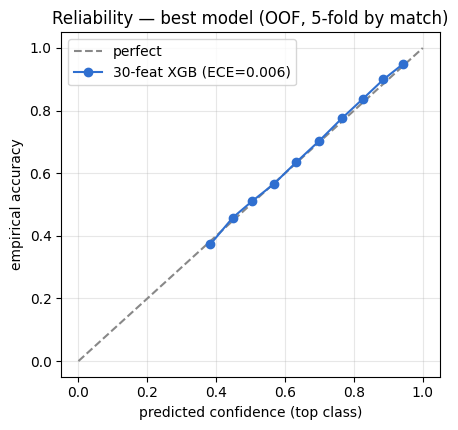

In [24]:
# 25 — Best-model validation: GroupKFold(5) CV (19 vs 30) + OOF calibration + reliability diagram
_y = dft["outcome_tag"].values; _g = dft["match_id"].values
_le = LabelEncoder().fit(["fail", "neutral", "success"]); _yi = _le.transform(_y); _CLS = list(_le.classes_)
_Yb = label_binarize(_y, classes=_CLS); _gkf = GroupKFold(n_splits=5)

def _cv(feats, oof=False):
    A, L = [], []; O = np.zeros((len(dft), 3)) if oof else None
    for _tr, _te in _gkf.split(dft, _y, _g):
        _m = XGBClassifier(**BEST_PARAMS, objective="multi:softprob", num_class=3, eval_metric="mlogloss",
                           tree_method="hist", n_jobs=-1, random_state=42).fit(dft[feats].iloc[_tr].astype(float), _yi[_tr])
        _p = _m.predict_proba(dft[feats].iloc[_te].astype(float))
        A.append(roc_auc_score(_Yb[_te], _p, average="macro")); L.append(log_loss(_y[_te], _p, labels=_CLS))
        if oof: O[_te] = _p
    return np.array(A), np.array(L), O

_a19, _l19, _ = _cv(FEATURE_NAMES)
_a30, _l30, _oof = _cv(ALL_FEATURES_BI, oof=True)
print("GroupKFold(5) by match:")
print(f"  19 static: AUC {_a19.mean():.4f}±{_a19.std():.4f} | log-loss {_l19.mean():.4f}±{_l19.std():.4f}")
print(f"  30 best  : AUC {_a30.mean():.4f}±{_a30.std():.4f} | log-loss {_l30.mean():.4f}±{_l30.std():.4f}")
print(f"  dAUC per fold {(_a30-_a19).round(4).tolist()} -> +{(_a30-_a19).mean():.4f}±{(_a30-_a19).std():.4f}")

_oh = np.eye(3)[_yi]
_brier = float(np.mean(np.sum((_oof - _oh) ** 2, 1))); _brier_ns = float(np.sum(_oh.mean(0) * (1 - _oh.mean(0))))
_conf = _oof.max(1); _pl = _oof.argmax(1); _acc = (_pl == _yi).astype(float)
_B = 15; _ece = 0.0; _xs, _ys = [], []
for _b in range(_B):
    _msk = (_conf > _b / _B) & (_conf <= (_b + 1) / _B)
    if _msk.sum():
        _ece += _msk.mean() * abs(_acc[_msk].mean() - _conf[_msk].mean()); _xs.append(_conf[_msk].mean()); _ys.append(_acc[_msk].mean())
print(f"\nOOF (30-feat): macro-AUC {roc_auc_score(_Yb, _oof, average='macro'):.4f} | log-loss {log_loss(_y, _oof, labels=_CLS):.4f}")
print(f"  ECE(top,15) {_ece:.4f} | Brier {_brier:.4f} (no-skill {_brier_ns:.4f})")
print("  per-class OvR AUC :", {_CLS[k]: round(float(roc_auc_score(_Yb[:, k], _oof[:, k])), 4) for k in range(3)})
print("  per-class OvR Brier:", {_CLS[k]: round(float(np.mean((_oof[:, k] - _oh[:, k]) ** 2)), 4) for k in range(3)})

fig, ax = plt.subplots(figsize=(4.6, 4.4))
ax.plot([0, 1], [0, 1], "--", color="#888", label="perfect")
ax.plot(_xs, _ys, "-o", color="#2F6FD0", label=f"30-feat XGB (ECE={_ece:.3f})")
ax.set_xlabel("predicted confidence (top class)"); ax.set_ylabel("empirical accuracy")
ax.set_title("Reliability — best model (OOF, 5-fold by match)"); ax.legend(loc="upper left"); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()


In [25]:
# 25e — De-collinearise the feature set (30 -> 17): VIF / |r| check + GroupKFold parity, then deploy on the pruned set
# Several of the 30 descriptors are near-duplicates within three collinear clusters
# (carrier-pressure, off-ball-pressure/receiver-freedom, ball_in cartesian<->polar) plus two redundant
# temporal diffs. Keep ONE representative per cluster. Tree-model accuracy is unaffected; feature
# importance / VAEP driver attribution become stable. (max VIF 13.2->2.2, max |r| 0.95->0.62.)
DROP_COLLINEAR = [
    "max_press_on_carrier", "nearest_def_dist", "n_pressers_on_carrier",  # carrier-pressure -> keep P_total, carrier_enemy_density
    "mean_lane_openness",                                                 # pass openness    -> keep n_open_pass / best_pass_w
    "n_press_on_attackers", "max_press_on_attacker", "min_recv_freedom",  # off-ball pressure/
    "mean_recv_freedom", "frac_attackers_pressed",                        #   receiver freedom -> keep total_press_on_attackers
    "d_nearest_def_dist_dt", "d_press_redistribution_dt",                 # redundant temporal diffs -> keep d_P_total_dt
    "ball_in_dx", "ball_in_dy",                                           # cartesian -> keep polar (ball_in_dist, ball_in_angle)
]
PRUNED_17 = [f for f in ALL_FEATURES_BI if f not in DROP_COLLINEAR]
assert len(PRUNED_17) == 17, len(PRUNED_17)
print(f"pruned {len(ALL_FEATURES_BI)} -> {len(PRUNED_17)} features:\n  " + ", ".join(PRUNED_17))

# --- collinearity before/after (median-imputed VIF + max |Pearson r|) ---
def _vif_maxr(cols):
    Z = dft[cols].astype(float); Z = Z.fillna(Z.median())
    Zs = (Z - Z.mean()) / Z.std(ddof=0)
    M = Zs.values; vif = {}
    for i, c in enumerate(cols):
        y = M[:, i]; Xo = np.delete(M, i, axis=1)
        b, *_ = np.linalg.lstsq(Xo, y, rcond=None)
        ss = ((y - y.mean()) ** 2).sum(); r2 = 1 - ((y - Xo @ b) ** 2).sum() / ss if ss > 0 else 0
        vif[c] = np.inf if r2 >= 1 else 1 / (1 - r2)
    C = np.abs(np.corrcoef(M, rowvar=False)); np.fill_diagonal(C, 0.0)
    return max(vif.values()), float(np.nanmax(C))
_v30, _r30 = _vif_maxr(ALL_FEATURES_BI); _v17, _r17 = _vif_maxr(PRUNED_17)
print(f"max VIF : {_v30:5.1f} -> {_v17:4.1f}   |   max |r| : {_r30:.2f} -> {_r17:.2f}")

# --- CV parity: reuse _cv (GroupKFold(5) by match, tuned XGB) from the validation cell above ---
_a30p, _l30p, _ = _cv(ALL_FEATURES_BI); _a17, _l17, _ = _cv(PRUNED_17)
print(f"GroupKFold(5): 30-feat AUC {_a30p.mean():.4f} logloss {_l30p.mean():.4f}  |  "
      f"17-feat AUC {_a17.mean():.4f} logloss {_l17.mean():.4f}  |  dAUC {_a17.mean()-_a30p.mean():+.4f}")


pruned 30 -> 17 features:
  P_total, carrier_enemy_density, carrier_friendly_density, carrier_dist_boundary, carrier_x_norm, best_pass_w, best_forward_pass_w, n_open_pass, total_press_on_attackers, carrier_trap_w, d_P_total_dt, d_carrier_x_norm_dt, d_best_pass_w_dt, d_carrier_trap_w_dt, d_frac_attackers_pressed_dt, ball_in_dist, ball_in_angle


max VIF :  12.3 ->  2.3   |   max |r| : 0.95 -> 0.61


GroupKFold(5): 30-feat AUC 0.7160 logloss 0.7593  |  17-feat AUC 0.7124 logloss 0.7624  |  dAUC -0.0035


## 校准选定模型 — 80/20 (train/calibrate) on 2024/25

The **selected model** (see *Selected model* above) is the **tuned, unweighted XGBoost on the
17 de-collinearised features** (`PRUNED_17`, see cell 25e). Cell #16 argued it is *already*
well-calibrated (ECE ≈ 0.006); here we verify that explicitly.

Split 2024/25 **by match** into **80% (train the tuned unweighted model) / 20% (fit an isotonic
calibrator)**, then compare **before vs after** on the held-out 20%: log-loss, accuracy,
macro-AUC, ECE (top-label + per-class), Brier per class. If the metrics barely move, the selected
model needs no calibration — and any residual issue on a new season (e.g. rarely predicting
`success`) is about **class weighting / drift**, not calibration.

In [26]:
# 25a — Calibrate the SELECTED model (tuned, UNWEIGHTED, 17-feat de-collinearised) — 80/20 train/calibrate on 2024/25
#        feature set: PRUNED_17 (de-collinearised; see cell 25e). build_feature_matrix still emits all 30 cols; we subset.
from sklearn.model_selection import GroupShuffleSplit
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator
import joblib

FEATS30 = PRUNED_17                                     # 17 de-collinearised features (see cell 25e)
Xa = dft[FEATS30].astype(float)
ya = le.transform(dft["outcome_tag"].values)
ga = dft["match_id"].values

# 80% train the model / 20% fit the calibrator (grouped by match)
trC, caC = next(GroupShuffleSplit(1, test_size=0.20, random_state=42).split(Xa, ya, ga))
print(f"train {len(trC)} ({pd.Series(ga[trC]).nunique()} matches) | "
      f"calibrate {len(caC)} ({pd.Series(ga[caC]).nunique()} matches) | {len(FEATS30)} feats")

# base = the selected model: tuned BEST_PARAMS, NO sample weights
base30 = XGBClassifier(**BEST_PARAMS, objective="multi:softprob", num_class=3,
                       eval_metric="mlogloss", tree_method="hist", n_jobs=-1, random_state=42)
base30.fit(Xa.iloc[trC], ya[trC])
cal30 = CalibratedClassifierCV(FrozenEstimator(base30), method="isotonic").fit(Xa.iloc[caC], ya[caC])

joblib.dump({"model": cal30, "base_model": base30, "label_encoder": le, "features": list(FEATS30),
             "params": BEST_PARAMS, "weighting": "unweighted", "calib_method": "isotonic"},
            os.path.join(HPN, "hpn_xgb_outcome_calibrated.joblib"))
print("saved -> hpn_xgb_outcome_calibrated.joblib  (tuned, unweighted, 17-feat, isotonic)")

train 87575 (300 matches) | calibrate 21857 (76 matches) | 17 feats


saved -> hpn_xgb_outcome_calibrated.joblib  (tuned, unweighted, 17-feat, isotonic)


,log_loss,accuracy,macro_AUC,ECE_top,ECE_fail,Brier_fail,ECE_neutral,Brier_neutral,ECE_success,Brier_success
model,,,,,,,,,,
uncalibrated,0.7620,0.6465,0.7151,0.0090,0.0127,0.2019,0.0125,0.2122,0.0017,0.0534
calibrated,0.7582,0.6480,0.7178,0.0039,0.0025,0.2012,0.0027,0.2113,0.0005,0.0532


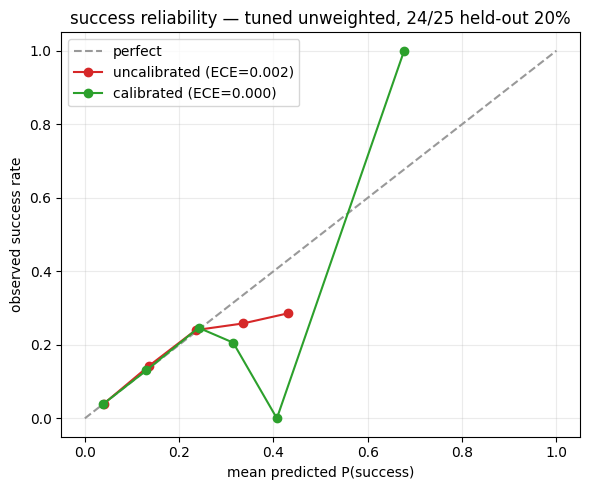

In [27]:
# 25b — Metrics BEFORE vs AFTER calibration, on the held-out 20% (tuned unweighted model)
import matplotlib.pyplot as plt
from sklearn.metrics import log_loss, brier_score_loss, accuracy_score, roc_auc_score
from sklearn.preprocessing import label_binarize

yv = ya[caC]
Pu = base30.predict_proba(Xa.iloc[caC])            # BEFORE calibration
Pc = cal30.predict_proba(Xa.iloc[caC])             # AFTER  calibration
CLSl = list(le.classes_); i_s = CLSl.index("success")

def _ece_top(P, y, nb=15):                          # top-label ECE (local; explicit y, no closure)
    conf, pl = P.max(1), P.argmax(1); acc = (pl == y).astype(float); e = 0.
    for b in range(nb):
        m = (conf > b/nb) & (conf <= (b+1)/nb)
        if m.sum(): e += m.mean() * abs(acc[m].mean() - conf[m].mean())
    return e
def ece_cls(yk, pk, nb=10):                         # per-class one-vs-rest ECE
    ed = np.linspace(0, 1, nb+1); idx = np.digitize(pk, ed[1:-1]); s = 0.
    for b in range(nb):
        m = idx == b
        if m.any(): s += m.sum()/len(pk) * abs(pk[m].mean() - yk[m].mean())
    return s

Yb = label_binarize(yv, classes=[0, 1, 2])
rows = []
for tag, P in [("uncalibrated", Pu), ("calibrated", Pc)]:
    r = {"model": tag, "log_loss": log_loss(yv, P, labels=[0, 1, 2]),
         "accuracy": accuracy_score(yv, P.argmax(1)),
         "macro_AUC": roc_auc_score(Yb, P, average="macro"), "ECE_top": _ece_top(P, yv)}
    for k, c in enumerate(CLSl):
        yk = (yv == k).astype(int)
        r[f"ECE_{c}"] = ece_cls(yk, P[:, k]); r[f"Brier_{c}"] = brier_score_loss(yk, P[:, k])
    rows.append(r)
comp_cal = pd.DataFrame(rows).set_index("model")
display(comp_cal.round(4))

# reliability — success class (the minority class of interest)
yk = (yv == i_s).astype(int)
fig, ax = plt.subplots(figsize=(6, 5)); ax.plot([0, 1], [0, 1], "--", color="#999", label="perfect")
for tag, P, col in [("uncalibrated", Pu, "#d62728"), ("calibrated", Pc, "#2ca02c")]:
    ed = np.linspace(0, 1, 11); idx = np.digitize(P[:, i_s], ed[1:-1]); bp, bt = [], []
    for b in range(10):
        m = idx == b
        if m.any(): bp.append(P[m, i_s].mean()); bt.append(yk[m].mean())
    ax.plot(bp, bt, "o-", color=col, label=f"{tag} (ECE={ece_cls(yk, P[:, i_s]):.3f})")
ax.set_xlabel("mean predicted P(success)"); ax.set_ylabel("observed success rate")
ax.set_title("success reliability — tuned unweighted, 24/25 held-out 20%")
ax.legend(); ax.grid(alpha=.25); plt.tight_layout(); plt.show()

## Balanced variants + calibration — does class weighting help `success`?

M1 (the selected model) is tuned **unweighted**: excellent probabilities, but it almost never
*predicts* `success` at argmax. Here we build two **balanced-weight** alternatives, calibrate them
the same way (80/20 isotonic), and compare all three on the held-out 20%:

- **M1** unweighted-tuned + cal — the selected model
- **M2** balanced, base params (#10) + cal
- **M3** balanced, **tuned** params + cal — hyperparameter search over the balanced fit

Question: after calibration, do the balanced variants buy meaningfully better minority handling,
and at what cost to log-loss / AUC?

In [28]:
# 25c — Balanced variants: tune (pinned) + fit M2 (base) & M3 (tuned), both calibrated
from sklearn.model_selection import GroupKFold
from sklearn.utils.class_weight import compute_sample_weight

RUN_SEARCH_BAL = False        # flip True to re-run the grouped search (~2 min)
BEST_BAL = {"n_estimators": 500, "max_depth": 6, "learning_rate": 0.05, "min_child_weight": 10,
            "subsample": 0.6, "colsample_bytree": 0.8, "gamma": 0.0, "reg_lambda": 2.0}  # pinned (CV logloss 0.906)
BASE10   = dict(n_estimators=500, max_depth=5, learning_rate=0.05, subsample=0.8,
                colsample_bytree=0.8, min_child_weight=5, reg_lambda=1.0)               # the #10 base config
_FIX = dict(objective="multi:softprob", num_class=3, eval_metric="mlogloss",
            tree_method="hist", n_jobs=-1, random_state=42)

if RUN_SEARCH_BAL:                             # GroupKFold(3) on the 80% TRAIN; fit balanced, score UNWEIGHTED log-loss
    rng = np.random.RandomState(42)
    SPACE = dict(n_estimators=[300,500,700], max_depth=[4,5,6], learning_rate=[0.02,0.03,0.05],
                 min_child_weight=[5,10,15], subsample=[0.6,0.8], colsample_bytree=[0.6,0.8],
                 gamma=[0.0,1.0,2.0], reg_lambda=[1.0,2.0,3.0])
    folds = list(GroupKFold(3).split(Xa.iloc[trC], ya[trC], ga[trC])); res = []
    for _ in range(15):
        pr = {k: rng.choice(v).item() for k, v in SPACE.items()}; ll = []
        for tf, vf in folds:
            Xt, yt = Xa.iloc[trC].iloc[tf], ya[trC][tf]
            m = XGBClassifier(**pr, **_FIX).fit(Xt, yt, sample_weight=compute_sample_weight("balanced", yt))
            ll.append(log_loss(ya[trC][vf], m.predict_proba(Xa.iloc[trC].iloc[vf]), labels=[0,1,2]))
        res.append((np.mean(ll), pr))
    res.sort(key=lambda x: x[0]); BEST_BAL = res[0][1]
    print("search best CV logloss", round(res[0][0], 4), "| BEST_BAL", BEST_BAL)

def _fit_cal(params, balanced):                # fit on 80% train, isotonic-calibrate on 20%
    b = XGBClassifier(**params, **_FIX)
    sw = compute_sample_weight("balanced", ya[trC]) if balanced else None
    b.fit(Xa.iloc[trC], ya[trC], sample_weight=sw)
    return b, CalibratedClassifierCV(FrozenEstimator(b), method="isotonic").fit(Xa.iloc[caC], ya[caC])

baseM2, calM2 = _fit_cal(BASE10,   True)       # M2 balanced-base
baseM3, calM3 = _fit_cal(BEST_BAL, True)       # M3 balanced-tuned
print("fitted M2 (balanced-base) & M3 (balanced-tuned), both isotonic-calibrated")

fitted M2 (balanced-base) & M3 (balanced-tuned), both isotonic-calibrated


,log_loss,accuracy,macro_AUC,success_recall,ECE_success,Brier_success
model,,,,,,
M1 unweighted-tuned,0.7582,0.6480,0.7178,0.0015,0.0005,0.0532
M2 balanced-base,0.7664,0.6414,0.7123,0.0107,0.0069,0.0537
M3 balanced-tuned,0.7663,0.6421,0.7112,0.0114,0.0067,0.0539


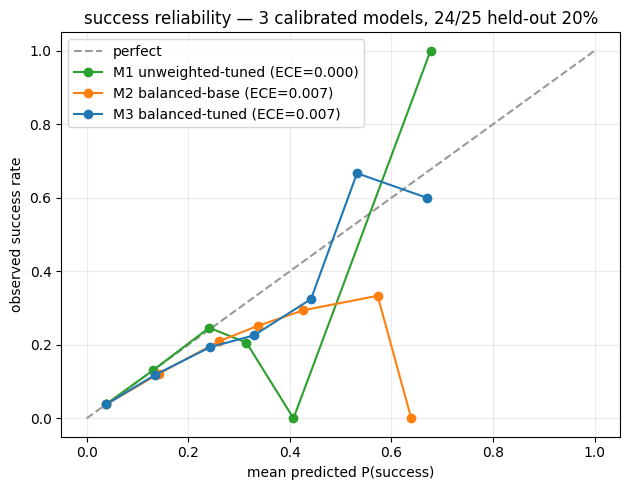

In [29]:
# 25d — 3-way comparison on the held-out 20% (all calibrated)
from sklearn.metrics import recall_score
yv = ya[caC]; Yb = label_binarize(yv, classes=[0, 1, 2]); i_s = list(le.classes_).index("success")
MODELS = {"M1 unweighted-tuned": cal30, "M2 balanced-base": calM2, "M3 balanced-tuned": calM3}
rows = []
for name, c in MODELS.items():
    P = c.predict_proba(Xa.iloc[caC])
    rows.append(dict(model=name, log_loss=log_loss(yv, P, labels=[0,1,2]),
        accuracy=accuracy_score(yv, P.argmax(1)), macro_AUC=roc_auc_score(Yb, P, average="macro"),
        success_recall=recall_score(yv, P.argmax(1), labels=[i_s], average="macro"),
        ECE_success=ece_cls((yv==i_s).astype(int), P[:, i_s]),
        Brier_success=brier_score_loss((yv==i_s).astype(int), P[:, i_s])))
comp3 = pd.DataFrame(rows).set_index("model").round(4)
display(comp3)

yk = (yv == i_s).astype(int)
fig, ax = plt.subplots(figsize=(6.4, 5)); ax.plot([0,1],[0,1],"--",color="#999",label="perfect")
for name, c, col in [("M1 unweighted-tuned", cal30, "#2ca02c"), ("M2 balanced-base", calM2, "#ff7f0e"),
                     ("M3 balanced-tuned", calM3, "#1f77b4")]:
    P = c.predict_proba(Xa.iloc[caC]); ed = np.linspace(0,1,11); idx = np.digitize(P[:,i_s], ed[1:-1]); bp, bt = [], []
    for b in range(10):
        m = idx == b
        if m.any(): bp.append(P[m,i_s].mean()); bt.append(yk[m].mean())
    ax.plot(bp, bt, "o-", color=col, label=f"{name} (ECE={ece_cls(yk, P[:,i_s]):.3f})")
ax.set_xlabel("mean predicted P(success)"); ax.set_ylabel("observed success rate")
ax.set_title("success reliability — 3 calibrated models, 24/25 held-out 20%"); ax.legend(); ax.grid(alpha=.25)
plt.tight_layout(); plt.show()

## VAEP-style step valuation — press effectiveness per event step

Use the calibrated 17-feature XGBoost to score each anchor in a pressing sequence with
$(p^s_t, p^f_t, p^n_t)$, then characterise the **inter-step transitions** that reveal
whether the pressing team's action at step $t{-}1$ moved the situation toward ball
recovery or allowed the ball-carrier to escape.

### Classification scheme (either-axis rule)

For each transition $t{-}1\!\to\!t$:

$$\Delta p^s_t = p^s_t - p^s_{t-1}, \quad \Delta p^f_t = p^f_t - p^f_{t-1}, \quad v_t = \Delta p^s_t - \Delta p^f_t$$

Each axis is reduced to a sign with a $\delta$ dead-band: $s=\mathrm{sgn}_\delta(\Delta p^s)$,
$f=\mathrm{sgn}_\delta(\Delta p^f)\in\{-1,0,+1\}$. A step is **substantive if *either* axis exceeds**
$\delta$ (single-sided moves count); only when **both** are inside the band is it noise.

| $s$ (success) | $f$ (fail) | label | press-team reading |
|:---:|:---:|---|---|
| $+1$ | $\le 0$ | **Effective** | success$\uparrow$, fail not rising — clean pressure gain |
| $+1$ | $+1$ | **Risky** (fav $v_t>0$ / adv $v_t<0$) | both tails grow — decisive but double-edged |
| $\le 0$ | $+1$ | **Beaten** | fail$\uparrow$, success not rising — carrier escaping |
| $-1$/$0$ | $\le 0$ | **De-escalation** | mass flows back to neutral (cooling down) |
| $0$ | $0$ | **Negligible** | both $\lvert\Delta p\rvert<\delta$ (dead zone) |

$\delta=$ 25th-percentile of the sequence's $|\Delta p|$ distribution; a sensitivity sweep is included.

In [30]:
# 26 — Find a long sequence and score every step with the deployed calibrated (17-feat) model
import joblib, numpy as np, pandas as pd

bundle = joblib.load("hpn_xgb_outcome_calibrated.joblib")   # deployed 17-feat calibrated model
model_vaep = bundle["model"]; le_vaep = bundle["label_encoder"]; feats_vaep = bundle["features"]
CLS_V = list(le_vaep.classes_)   # ['fail','neutral','success']
i_s = CLS_V.index("success"); i_f = CLS_V.index("fail"); i_n = CLS_V.index("neutral")

# pick the longest sequence (by anchor count) in the dataset
seq_lens = (dft.groupby(["match_id", "seq_id"])["ev_pos"]
              .count().rename("n_steps").reset_index()
              .sort_values("n_steps", ascending=False))
print("Top 10 longest sequences:")
print(seq_lens.head(10).to_string(index=False))

# select sequence with most steps
row0 = seq_lens.iloc[0]
MID, SID = str(row0["match_id"]), int(row0["seq_id"])
print(f"\n→ using match {MID}, seq {SID}  ({int(row0['n_steps'])} steps)")

Top 10 longest sequences:
match_id  seq_id  n_steps
 3955969      28       23
 3955965      92       23
 3955902      48       22
 3955827      74       21
 3955947      83       21
 3955866     124       21
 3955635      17       20
 3955758       8       20
 3955770     105       20
 3955684      13       19

→ using match 3955969, seq 28  (23 steps)


delta = 0.0513  (25th-pct of |dp| distribution in this sequence)
sequence outcome: fail  |  terminal: False
step labels: ['Effective', 'De-escalation', 'Risky-adv', 'Effective', 'De-escalation', 'Beaten', 'De-escalation', 'Beaten', 'Beaten', 'De-escalation', 'Beaten', 'Beaten', 'Risky-adv', 'De-escalation', 'Effective', 'De-escalation', 'Beaten', 'Risky-fav', 'De-escalation', 'Risky-adv', 'De-escalation', 'Beaten']
v_t (net press value): [0.308, -0.083, -0.413, 0.539, -0.053, -0.123, 0.171, -0.188, -0.078, 0.156, -0.109, -0.205, -0.055, 0.233, 0.034, 0.216, -0.072, 0.051, -0.077, -0.094, 0.078, -0.154]


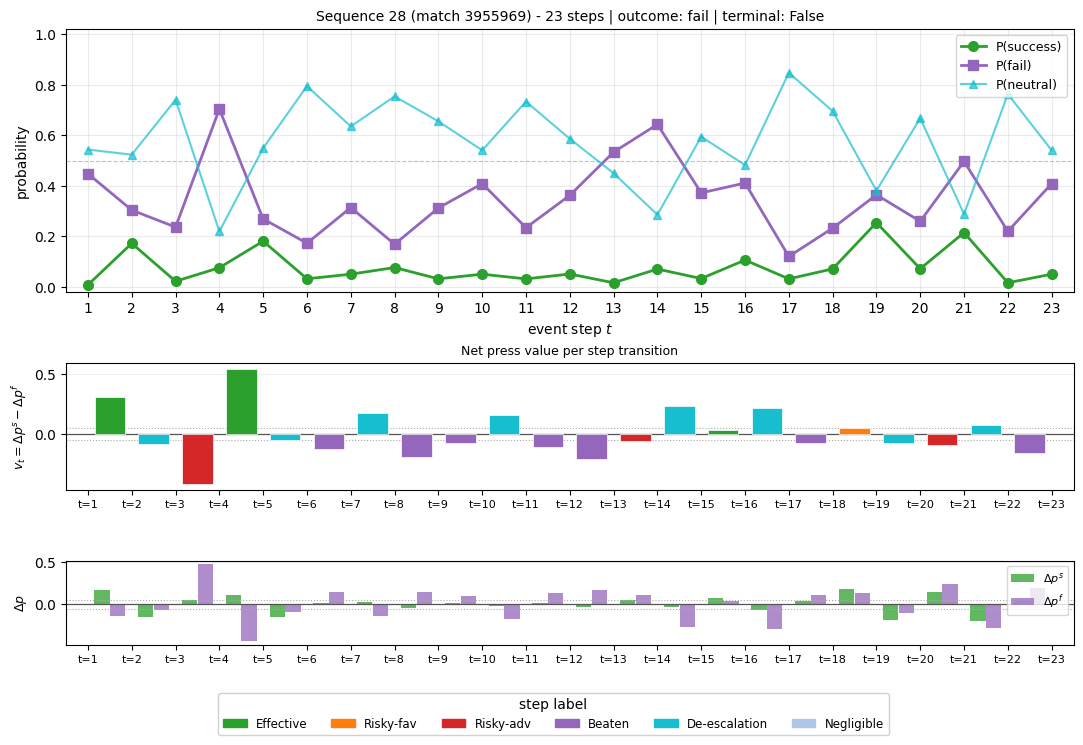


Step-level VAEP table:
 step  P(s)  P(f)  P(n)   dp_s   dp_f    v_t         label
    1 0.009 0.448 0.543    NaN    NaN    NaN       (start)
    2 0.173 0.304 0.523  0.164 -0.144  0.308     Effective
    3 0.023 0.237 0.740 -0.150 -0.067 -0.083 De-escalation
    4 0.076 0.703 0.220  0.054  0.467 -0.413     Risky-adv
    5 0.181 0.269 0.549  0.105 -0.434  0.539     Effective
    6 0.033 0.173 0.794 -0.149 -0.096 -0.053 De-escalation
    7 0.051 0.314 0.635  0.018  0.141 -0.123        Beaten
    8 0.077 0.169 0.753  0.026 -0.145  0.171 De-escalation
    9 0.033 0.313 0.655 -0.045  0.143 -0.188        Beaten
   10 0.051 0.409 0.540  0.018  0.096 -0.078        Beaten
   11 0.032 0.235 0.733 -0.019 -0.174  0.156 De-escalation
   12 0.052 0.363 0.586  0.019  0.128 -0.109        Beaten
   13 0.017 0.533 0.450 -0.035  0.171 -0.205        Beaten
   14 0.071 0.643 0.286  0.054  0.110 -0.055     Risky-adv
   15 0.034 0.372 0.594 -0.038 -0.271  0.233 De-escalation
   16 0.107 0.411 0.482  0.073  

In [31]:
# 27 — Step-level probabilities -> four-quadrant VAEP valuation + visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

# ── 1. extract sequence ──────────────────────────────────────────────────────
seq = (dft[(dft["match_id"] == MID) & (dft["seq_id"] == SID)]
       .sort_values("ev_pos").reset_index(drop=True))
X_seq = seq[feats_vaep].astype(float)
proba_seq = model_vaep.predict_proba(X_seq)          # shape (T, 3)  order = ['fail','neutral','success']
ps = proba_seq[:, i_s]   # P(success)
pf = proba_seq[:, i_f]   # P(fail)
pn = proba_seq[:, i_n]   # P(neutral)
T  = len(seq)
steps = np.arange(1, T + 1)

# ── 2. inter-step differences ────────────────────────────────────────────────
dps = np.diff(ps);  dpf = np.diff(pf)
vt  = dps - dpf            # net press value (+= toward regain; -= toward escape)

# ── 3. delta = 25th-pct of |dp| in this sequence ─────────────────────────────
all_abs = np.concatenate([np.abs(dps), np.abs(dpf)])
DELTA = float(np.percentile(all_abs, 25))
print(f"delta = {DELTA:.4f}  (25th-pct of |dp| distribution in this sequence)")

# ── 4. four-quadrant classification (either-axis rule) ───────────────────────
COLORS = {"Effective": "#2ca02c", "Risky-fav": "#ff7f0e", "Risky-adv": "#d62728",
          "Beaten": "#9467bd", "De-escalation": "#17becf", "Negligible": "#aec7e8"}

def classify(ds, df_, vt_, delta):
    # either-axis rule: a step is substantive if EITHER axis exceeds delta.
    s = 1 if ds > delta else (-1 if ds < -delta else 0)   # success-axis sign w/ delta deadband
    f = 1 if df_ > delta else (-1 if df_ < -delta else 0)  # fail-axis sign w/ delta deadband
    if s == 0 and f == 0:
        return "Negligible"                     # dead zone: neither axis moves
    if s == 1 and f == 1:
        return "Risky-fav" if vt_ > 0 else "Risky-adv"
    if s == 1 and f <= 0:                        # success up, fail flat/down -> clean gain
        return "Effective"
    if s <= 0 and f == 1:                        # fail up, success flat/down -> press beaten
        return "Beaten"
    return "De-escalation"                       # (-,-)/(-,0)/(0,-): de-escalation to neutral

labels = [classify(dps[i], dpf[i], vt[i], DELTA) for i in range(T - 1)]
outcome_true = seq["outcome_tag"].iloc[-1]
terminal_true = bool(seq["terminal"].iloc[-1])
print(f"sequence outcome: {outcome_true}  |  terminal: {terminal_true}")
print(f"step labels: {labels}")
print(f"v_t (net press value): {np.round(vt, 3).tolist()}")

# ── 5. plot ───────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(13, 8))
gs  = GridSpec(3, 1, figure=fig, height_ratios=[2.5, 1.2, 0.8], hspace=0.45)

# panel A — probability trajectory
ax1 = fig.add_subplot(gs[0])
ax1.plot(steps, ps, "o-", color="#2ca02c", lw=2, ms=7, label="P(success)")
ax1.plot(steps, pf, "s-", color="#9467bd", lw=2, ms=7, label="P(fail)")
ax1.plot(steps, pn, "^-", color="#17becf", lw=1.5, ms=6, label="P(neutral)", alpha=0.7)
ax1.axhline(0.5, color="#888", ls="--", lw=0.8, alpha=0.5)
ax1.set_xlim(0.5, T + 0.5); ax1.set_ylim(-0.02, 1.02)
ax1.set_xticks(steps); ax1.set_xlabel("event step $t$")
ax1.set_ylabel("probability"); ax1.legend(loc="upper right", fontsize=9)
ax1.set_title(f"Sequence {SID} (match {MID}) - {T} steps | outcome: {outcome_true} | terminal: {terminal_true}",
              fontsize=10)
ax1.grid(alpha=0.25)

# panel B — v_t bar (net press value), colored by quadrant
ax2 = fig.add_subplot(gs[1])
bar_x = np.arange(1.5, T + 0.5)           # midpoints between steps
for i, (x, v, lbl) in enumerate(zip(bar_x, vt, labels)):
    ax2.bar(x, v, width=0.7, color=COLORS[lbl], edgecolor="white", linewidth=0.5, zorder=3)
ax2.axhline(0, color="#555", lw=0.9)
ax2.axhline( DELTA, color="#aaa", ls=":", lw=0.8)
ax2.axhline(-DELTA, color="#aaa", ls=":", lw=0.8)
ax2.set_xlim(0.5, T + 0.5); ax2.set_ylim(min(vt) - 0.05, max(vt) + 0.05)
ax2.set_xticks(steps); ax2.set_xticklabels([f"t={s}" for s in steps], fontsize=8)
ax2.set_ylabel("$v_t = \\Delta p^s - \\Delta p^f$", fontsize=9)
ax2.set_title("Net press value per step transition", fontsize=9)
ax2.grid(alpha=0.2, axis="y")

# panel C — dp_s / dp_f detail
ax3 = fig.add_subplot(gs[2])
ax3.bar(bar_x - 0.18, dps, 0.35, color="#2ca02c", alpha=0.75, label="$\\Delta p^s$")
ax3.bar(bar_x + 0.18, dpf, 0.35, color="#9467bd", alpha=0.75, label="$\\Delta p^f$")
ax3.axhline(0,      color="#555", lw=0.9)
ax3.axhline( DELTA, color="#aaa", ls=":", lw=0.8)
ax3.axhline(-DELTA, color="#aaa", ls=":", lw=0.8)
ax3.set_xlim(0.5, T + 0.5); ax3.set_xticks(steps)
ax3.set_xticklabels([f"t={s}" for s in steps], fontsize=8)
ax3.set_ylabel("$\\Delta p$", fontsize=9); ax3.legend(fontsize=8, loc="upper right"); ax3.grid(alpha=0.2, axis="y")

# legend patches for quadrant colors
patches = [mpatches.Patch(color=v, label=k) for k, v in COLORS.items()]
fig.legend(handles=patches, loc="lower center", ncol=6, fontsize=8.5,
           bbox_to_anchor=(0.5, -0.01), framealpha=0.9, title="step label")

plt.tight_layout()
plt.show()

# ── 6. step-level summary table ───────────────────────────────────────────────
summary = pd.DataFrame({
    "step": steps,
    "P(s)": np.round(ps, 3), "P(f)": np.round(pf, 3), "P(n)": np.round(pn, 3),
    "dp_s": np.round(np.concatenate([[np.nan], dps]), 3),
    "dp_f": np.round(np.concatenate([[np.nan], dpf]), 3),
    "v_t":  np.round(np.concatenate([[np.nan], vt]),  3),
    "label": ["(start)"] + labels,
})
print("\nStep-level VAEP table:")
print(summary.to_string(index=False))

# ── 7. telescoping sanity check ───────────────────────────────────────────────
print(f"\n[sanity] sum dp_s = {dps.sum():.4f}  vs  p_s_T - p_s_0 = {ps[-1]-ps[0]:.4f}")
print(f"         sum  v_t = {vt.sum():.4f}  vs  (p_s_T-p_f_T)-(p_s_0-p_f_0) = {(ps[-1]-pf[-1])-(ps[0]-pf[0]):.4f}")

# ── 8. delta sensitivity ─────────────────────────────────────────────────────
print(f"\ndelta sensitivity:")
print(f"{'delta':>7}  {'Effective':>9}  {'Risky-fav':>9}  {'Risky-adv':>9}  {'Beaten':>7}  {'De-escal':>8}  {'Neglig':>7}")
for pct in [10, 25, 50]:
    dd = float(np.percentile(all_abs, pct))
    lb = [classify(dps[i], dpf[i], vt[i], dd) for i in range(T - 1)]
    cnt = {k: lb.count(k) for k in COLORS}
    print(f"{dd:>7.3f}  {cnt['Effective']:>9}  {cnt['Risky-fav']:>9}  "
          f"{cnt['Risky-adv']:>9}  {cnt['Beaten']:>7}  {cnt['De-escalation']:>8}  {cnt['Negligible']:>7}")

**Reading the demo.** *Top:* the three outcome probabilities along the sequence (neutral high = stalemate; success/fail rising = the situation resolving). *Middle:* per-step $v_t$ coloured by label (green Effective … purple Beaten … cyan De-escalation). *Bottom:* the same split into $\Delta p^s$ and $\Delta p^f$; dotted lines mark $\pm\delta$. The tall green bar at $t{=}30$ is the decisive press-win moment; the run of purple near the end is the carrier repeatedly breaking out before the ball is finally regained.

## Full-season press valuation — all teams (2025/26)

Apply the step valuation (either-axis rule + $v_t$) to **every high-press anchor of the held-out
2025/26 season** (~104k frames -> 63,194 within-sequence transitions, all **20 teams**), scored
**directly** with the deployed **calibrated M1** (tuned, unweighted, isotonic, 17 features) — no
out-of-fold needed since 2025/26 is fully held out from training. Each transition is attributed to
the **pressing team** = the opponent of the in-possession team at that anchor.

Pressure is decomposed into channels, each differenced within the sequence ($\Delta t=1$): **carrier
total** (`P_total`), **single strongest presser** (`max_press_on_carrier`), **teammates**
(`total_press_on_attackers`, `max_press_on_attacker`, `frac_attackers_pressed`), **boundary trap**
(`carrier_trap_w`), plus nearest-defender distance and best-pass openness. We rank all 20 teams by
per-step press value and read which channel changes drive $v_t$.

In [32]:
# 28 — 2025/26 VAEP: build feature matrix, score with the deployed calibrated M1 (17-feat), step table + v_t
import matplotlib.pyplot as plt, joblib
from hpn_features import build_feature_matrix, FEATURES as FEATS_BI, GK as _GK

FEAT_2526   = os.environ.get("FEAT_PARQUET_2526", os.path.join(HPN, "hpn_carrier_features_2025_2026.parquet"))
LAB_2526    = os.environ.get("LABELS_2526",       os.path.join(HPN, "labels_2025_2026.csv"))
EVENTS_2526 = os.environ.get("EVENTS_DIR_2526",   os.path.join(DATA_DIR, "events_2025_2026"))  # bring your own 25/26 events (see README)

dft26 = build_feature_matrix(FEAT_2526, LAB_2526, EVENTS_2526)
lab26 = pd.read_csv(LAB_2526); lab26["match_id"] = lab26["match_id"].astype(str)
_b = joblib.load(os.path.join(HPN, "hpn_xgb_outcome_calibrated.joblib"))       # deployed M1
M1, le26, FEATS_M1 = _b["model"], _b["label_encoder"], _b["features"]
proba26 = M1.predict_proba(dft26[FEATS_M1].astype(float))
CLS = list(le26.classes_); i_s, i_f = CLS.index("success"), CLS.index("fail")
print(f"25/26: {dft26.shape} | matches {dft26['match_id'].nunique()} | scored with calibrated M1 ({len(FEATS_M1)} feats)")

labV = lab26[lab26["outcome_tag"].isin(OUTCOME_CLASSES)]
pressed = labV.set_index(["match_id","seq_id","ev_pos"])["team_name"].to_dict()
mteams  = {m: list(v) for m, v in labV.groupby("match_id")["team_name"].unique().items()}
vp26 = dft26[["match_id","seq_id","ev_pos","outcome_tag"]].copy().reset_index(drop=True)
vp26["pressed_team"] = [pressed.get((m,s,e)) for m,s,e in zip(vp26.match_id, vp26.seq_id, vp26.ev_pos)]
vp26["press_team"]   = [next((t for t in mteams.get(m,[]) if t != p), None)
                        for m,p in zip(vp26.match_id, vp26.pressed_team)]
vp26["p_s"] = proba26[:, i_s]; vp26["p_f"] = proba26[:, i_f]

CH = {"d_Ptot":"P_total","d_maxcar":"max_press_on_carrier","d_totatt":"total_press_on_attackers",
      "d_maxatt":"max_press_on_attacker","d_fracpr":"frac_attackers_pressed","d_trap":"carrier_trap_w",
      "d_neardef":"nearest_def_dist","d_bestpass":"best_pass_w"}
for c in CH.values(): vp26[c] = dft26[c].values
for nf, base in CH.items(): vp26[nf] = vp26.groupby(_GK)[base].diff()
vp26["dps"] = vp26.groupby(_GK)["p_s"].diff(); vp26["dpf"] = vp26.groupby(_GK)["p_f"].diff()
vp26["vt"]  = vp26["dps"] - vp26["dpf"]

_msk = vp26["vt"].notna()
DELTA_G = float(np.percentile(np.concatenate([vp26.loc[_msk,"dps"].abs(), vp26.loc[_msk,"dpf"].abs()]), 25))
def _classify_g(ds, df_, vt_, dd):
    if np.isnan(ds): return None
    s = 1 if ds > dd else (-1 if ds < -dd else 0)
    f = 1 if df_ > dd else (-1 if df_ < -dd else 0)
    if s == 0 and f == 0: return "Negligible"
    if s == 1 and f == 1: return "Risky-fav" if vt_ > 0 else "Risky-adv"
    if s == 1 and f <= 0: return "Effective"
    if s <= 0 and f == 1: return "Beaten"
    return "De-escalation"
vp26["label"] = [_classify_g(a,b,c,DELTA_G) for a,b,c in zip(vp26.dps, vp26.dpf, vp26.vt)]
print(f"global delta = {DELTA_G:.4f} | step transitions {int(_msk.sum())} | teams {vp26['press_team'].nunique()}")
print(vp26.loc[_msk,"label"].value_counts(normalize=True).round(4).to_string())

25/26: (104490, 36) | matches 310 | scored with calibrated M1 (17 feats)


global delta = 0.0264 | step transitions 63194 | teams 20
label
De-escalation    0.3652
Risky-adv        0.2041
Effective        0.1737
Beaten           0.1651
Negligible       0.0570
Risky-fav        0.0349


### Team regain-efficiency — metric definitions

Four complementary angles on how well a team's high press wins the ball back (table sorted by
`regain_rate`). The old per-step `mean_vt` is **dropped** — dividing by step count penalises teams
that run longer pressing sequences.

| metric | definition | reads as |
|---|---|---|
| **`regain_rate`** ① | share of the team's pressing **sequences** ending in a regain (`outcome_tag == success` at the last frame) | **ground truth** — did the press actually win the ball (model-free) |
| **`mean_p_s` / `mean_p_f`** ② | mean calibrated-M1 P(success) / P(fail) over **all** the team's pressing frames | expected regain / escape likelihood of the situations it creates (calibrated ⇒ `mean_p_s` ≈ frame-level regain frequency) |
| **`vt_per_seq`** ③a | `sum(v_t)/n_seq` — press value summed **within** each sequence, averaged **per sequence** (not per step) | **length-neutral value**: net Δ(p_s−p_f) a press achieves start→end, regardless of touch count. Fixes the `mean_vt` dilution |
| **`resid_vt`** ③b | actual per-step mean `v_t` **minus** the value expected from the team's sequence-length mix (league per-position baseline) | value **added per step beyond what its sequence lengths predict** — a length-adjusted over/under-performance |
| **`eff_over_EB`** ④ | `Effective / (Effective + Beaten)` = share of *decisive* steps that were Effective (= `sigmoid(log(Effective/Beaten))`, bounded [0,1]) | **process quality**: when a step is decisive, how often it favours the presser — orthogonal to outcome |

①② lean on **outcome** (calibration ties `mean_p_s` to `regain_rate`); ③ measures **value created**; ④ measures **process cleanliness**. E.g. Manchester City ranks high on ①/③a but only mid on ④ — its press is high-variance / `Risky`-heavy.

In [33]:
# 29 — 2025/26: team intensity + efficiency tables
for c in ["carrier_x_norm","n_pressers_on_carrier"]:
    if c not in vp26.columns: vp26[c] = dft26[c].values
vp26["seqkey"] = vp26["match_id"] + "_" + vp26["seq_id"].astype(str)
gA = vp26.groupby("press_team"); nm = gA["match_id"].nunique()
intensity26 = pd.DataFrame({"n_match": nm, "frames_per_match": gA.size()/nm,
    "seq_per_match": gA["seqkey"].nunique()/nm, "steps_per_seq": gA.size()/gA["seqkey"].nunique(),
    "mean_Ptot": gA["P_total"].mean()})
# ── team regain-efficiency: 4 complementary metrics (per-step mean_vt dropped: it dilutes long sequences) ──
sv = vp26.dropna(subset=["vt"]).copy()
sv["pos"] = sv["ev_pos"].clip(upper=8)
_league_pos = sv.groupby("pos")["vt"].mean()                       # league per-position v_t baseline
sv["exp_vt"] = sv["pos"].map(_league_pos)
gV = sv.groupby("press_team")
lab_eb = sv.groupby("press_team")["label"].value_counts().unstack(fill_value=0)
seq26 = vp26.groupby(["press_team", "seqkey"]).agg(                # per-sequence rollup
    endtag=("outcome_tag", "last"), sum_vt=("vt", "sum")).reset_index()
gS = seq26.groupby("press_team")
team26 = pd.DataFrame({
    "n_seq":       gS.size(),
    "regain_rate": gS["endtag"].apply(lambda s: (s == "success").mean()),           # 1  outcome (model-free)
    "mean_p_s":    gA["p_s"].mean(), "mean_p_f": gA["p_f"].mean(),                   # 2  expected prob (calibrated M1)
    "vt_per_seq":  gS["sum_vt"].mean(),                                             # 3a length-neutral value
    "resid_vt":    gV["vt"].mean() - gV["exp_vt"].mean(),                           # 3b length-adjusted residual
    "eff_over_EB": lab_eb["Effective"] / (lab_eb["Effective"] + lab_eb["Beaten"]),  # 4  process quality
}).sort_values("regain_rate", ascending=False)
display(team26.round(4))

,n_seq,regain_rate,mean_p_s,mean_p_f,vt_per_seq,resid_vt,eff_over_EB
press_team,,,,,,,
Liverpool,1898,0.3361,0.0574,0.3738,0.0577,0.0012,0.5396
Manchester City,1922,0.3314,0.0607,0.3604,0.0610,0.0000,0.5210
Newcastle United,2032,0.3189,0.0578,0.3707,0.0595,0.0013,0.5466
Brighton & Hove Albion,2147,0.3102,0.0605,0.3656,0.0609,0.0012,0.5409
Manchester United,2093,0.3063,0.0556,0.3624,0.0568,-0.0004,0.5085
Leeds United,2065,0.3056,0.0567,0.3613,0.0653,0.0042,0.5208
Tottenham Hotspur,1956,0.3011,0.0565,0.3672,0.0580,0.0012,0.5388
Chelsea,1894,0.2946,0.0561,0.3599,0.0514,-0.0044,0.5090
Arsenal,1996,0.2906,0.0583,0.3709,0.0552,-0.0013,0.5049


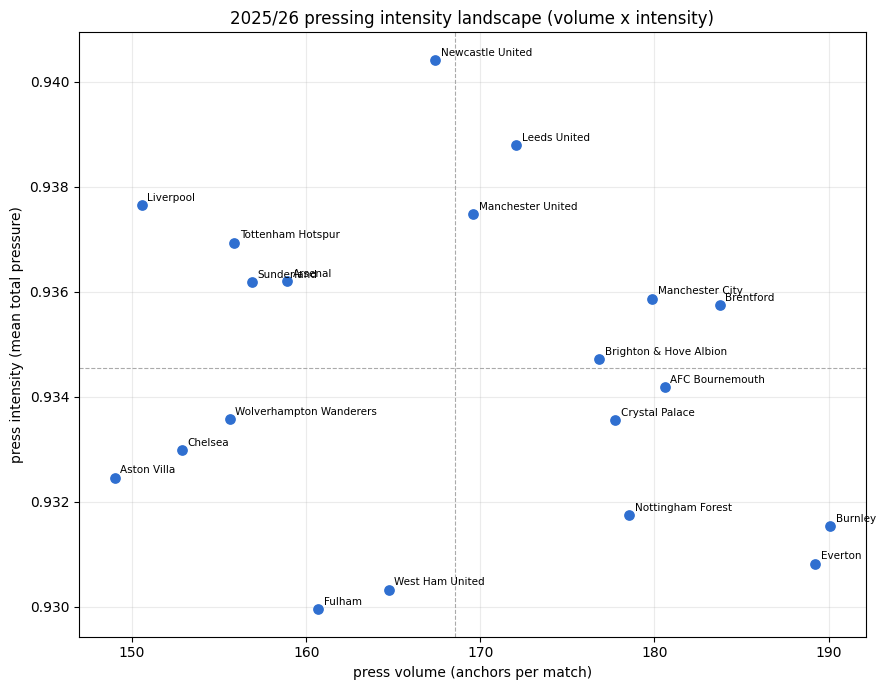

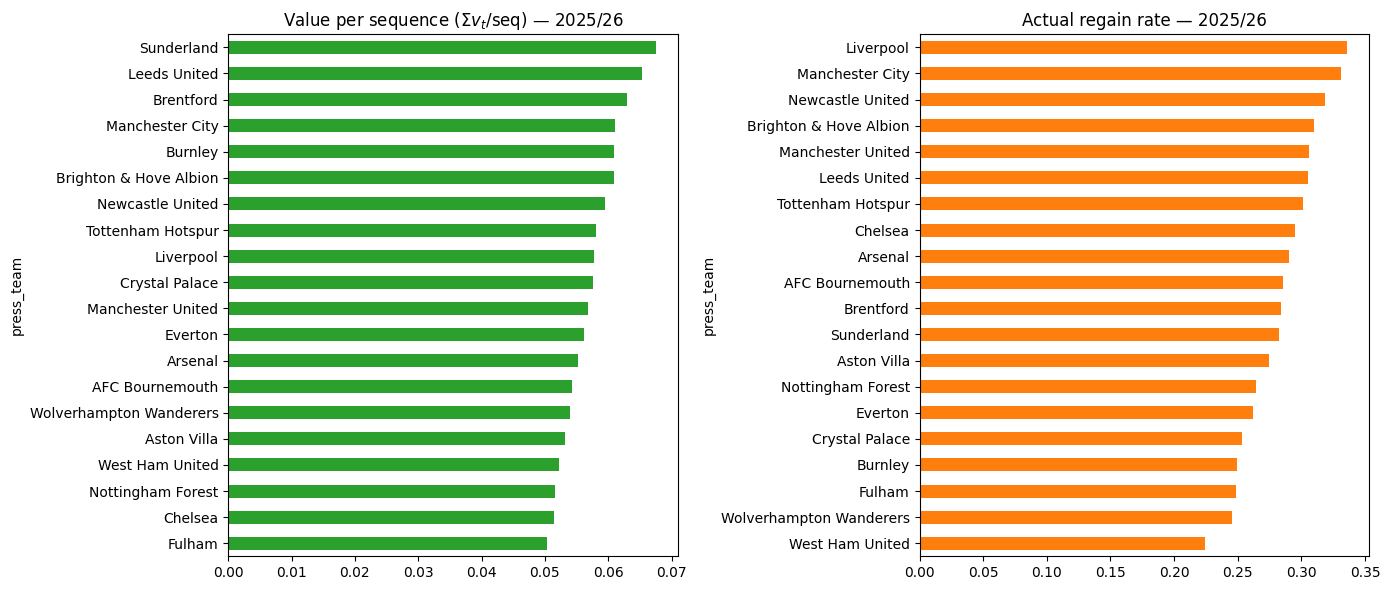

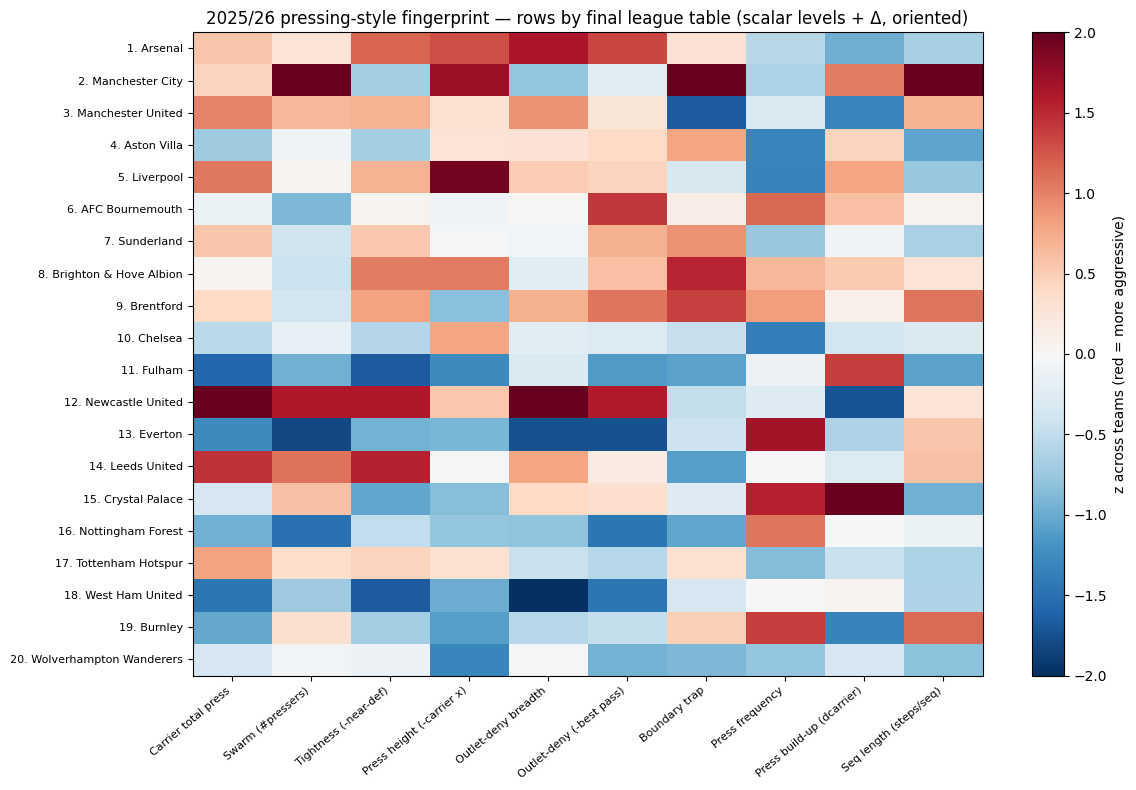

In [34]:
# 30 — 2025/26: intensity landscape + efficiency + pressing-style fingerprint (inline)
fig, ax = plt.subplots(figsize=(9,7))
x = intensity26["frames_per_match"]; y = intensity26["mean_Ptot"]
ax.scatter(x, y, s=45, color="#2F6FD0", zorder=3)
for t in intensity26.index: ax.annotate(t,(x[t],y[t]),fontsize=7.5,xytext=(4,3),textcoords="offset points")
ax.axvline(x.mean(),color="#aaa",ls="--",lw=.8); ax.axhline(y.mean(),color="#aaa",ls="--",lw=.8)
ax.set_xlabel("press volume (anchors per match)"); ax.set_ylabel("press intensity (mean total pressure)")
ax.set_title("2025/26 pressing intensity landscape (volume x intensity)"); ax.grid(alpha=.25)
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(1,2,figsize=(14,6))
vps = team26["vt_per_seq"].sort_values()
vps.plot.barh(ax=ax[0], color=["#d62728" if v<0 else "#2ca02c" for v in vps]); ax[0].set_title("Value per sequence ($\\Sigma v_t$/seq) — 2025/26")
team26["regain_rate"].sort_values().plot.barh(ax=ax[1], color="#ff7f0e"); ax[1].set_title("Actual regain rate — 2025/26")
plt.tight_layout(); plt.show()

STYLE=[("Carrier total press","P_total","frame",+1),("Swarm (#pressers)","n_pressers_on_carrier","frame",+1),
       ("Tightness (-near-def)","nearest_def_dist","frame",-1),("Press height (-carrier x)","carrier_x_norm","frame",-1),
       ("Outlet-deny breadth","frac_attackers_pressed","frame",+1),("Outlet-deny (-best pass)","best_pass_w","frame",-1),
       ("Boundary trap","carrier_trap_w","frame",+1),("Press frequency","seq_per_match","team",+1),
       ("Press build-up (dcarrier)","d_Ptot","frame",+1),("Seq length (steps/seq)","steps_per_seq","team",+1)]
cols={}
for name,src,scope,sgn in STYLE:
    cols[name] = sgn*(intensity26[src] if scope=="team" else vp26.groupby("press_team")[src].mean())
LEAGUE_ORDER = ["Arsenal", "Manchester City", "Manchester United", "Aston Villa", "Liverpool",
                "AFC Bournemouth", "Sunderland", "Brighton & Hove Albion", "Brentford", "Chelsea",
                "Fulham", "Newcastle United", "Everton", "Leeds United", "Crystal Palace",
                "Nottingham Forest", "Tottenham Hotspur", "West Ham United", "Burnley",
                "Wolverhampton Wanderers"]   # 2025/26 EPL final table (1st -> 20th, top -> bottom)
style = pd.DataFrame(cols).reindex(LEAGUE_ORDER)
Zt = (style-style.mean())/style.std()
fig, ax = plt.subplots(figsize=(12,8)); im = ax.imshow(Zt.values, cmap="RdBu_r", aspect="auto", vmin=-2, vmax=2)
ax.set_xticks(range(len(Zt.columns))); ax.set_xticklabels(Zt.columns, rotation=40, ha="right", fontsize=8)
ax.set_yticks(range(len(Zt.index))); ax.set_yticklabels([f"{i+1}. {t}" for i, t in enumerate(Zt.index)], fontsize=8)
fig.colorbar(im, label="z across teams (red = more aggressive)")
ax.set_title("2025/26 pressing-style fingerprint — rows by final league table (scalar levels + Δ, oriented)")
plt.tight_layout(); plt.show()

**Reading the team figures.** *Intensity landscape:* each team placed by press **volume** (anchors per match, x-axis) vs press **intensity** (mean total pressure on the carrier, y-axis); dashed lines mark league means, so the top-right quadrant is "relentless" (high volume *and* intensity). *Efficiency:* **value per sequence** ($\\sum v_t$/seq, left) and **actual regain rate** (right) — the full four-metric table is defined above. We deliberately **drop the per-step `mean_vt`**: dividing by step count **dilutes long-sequence teams** (Manchester City runs the longest sequences and would land near-last on `mean_vt`, despite ranking #2 on actual regain and top-6 on `vt_per_seq`).

**Reading the style fingerprint.** Rows = teams (ordered by **2025/26 final league position**, 1st at top), columns = pressing-style descriptors from **scalar levels** (team mean over *all* pressing frames) plus two **momentum** ($\Delta$) terms. Each column is **oriented so higher = more aggressive** (a $-$ in the label means the raw feature was negated, e.g. *tightness* $=-$nearest-defender distance) and **z-scored down the column**: red = above league average on that dimension, blue = below. A row is the team's pressing signature (ball-hunting, high line, outlet denial, touchline trap, frequency, escalation speed) — style, not strength.

joint linear R^2 = 0.022 (channels collinear -> betas unreliable)


,pearson_r_vt,mean_Effective,mean_Beaten,Eff_minus_Beaten,std_reg_beta
Boundary trap Δ,0.0878,0.0286,-0.0272,0.0558,0.0181
Best pass openness Δ,0.0591,-0.0341,0.0118,-0.0458,0.0176
Frac attackers pressed Δ,0.0317,0.0017,-0.0109,0.0126,0.0149
Max press on attacker Δ,0.0142,0.0028,0.0020,0.0009,0.0003
Carrier total press Δ,0.0008,0.0291,-0.0201,0.0492,0.0151
Nearest-def dist Δ,-0.0023,-0.6743,0.4981,-1.1724,-0.0218
Total press on attackers Δ,-0.0195,-0.2473,-0.0069,-0.2404,-0.0107
Max press on carrier Δ,-0.0238,0.0402,-0.0259,0.0661,-0.0325


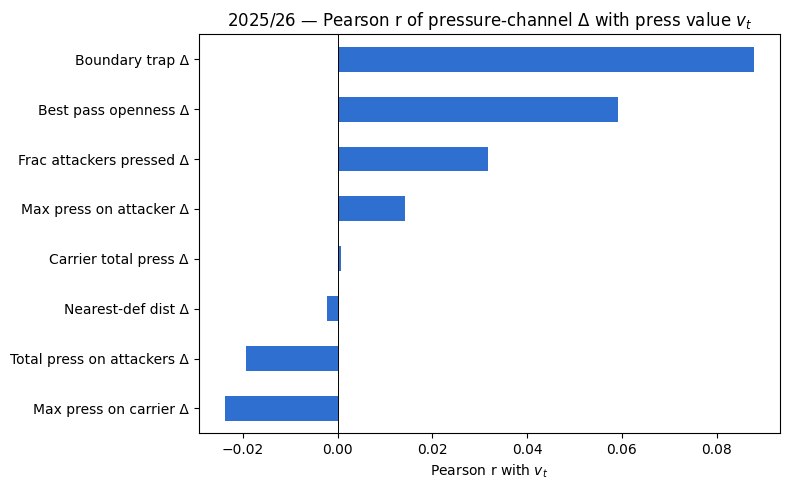

In [35]:
# 31 — 2025/26: drivers of press value v_t (which pressure-channel Δ raise v_t?)
import scipy.stats as st
from sklearn.linear_model import LinearRegression
CHNAME = {"d_Ptot":"Carrier total press Δ","d_maxcar":"Max press on carrier Δ",
          "d_totatt":"Total press on attackers Δ","d_maxatt":"Max press on attacker Δ",
          "d_fracpr":"Frac attackers pressed Δ","d_trap":"Boundary trap Δ",
          "d_neardef":"Nearest-def dist Δ","d_bestpass":"Best pass openness Δ"}
CHCOLS = list(CHNAME)
_sub = vp26.dropna(subset=["vt"]+CHCOLS)
drivers26 = pd.DataFrame({
    "pearson_r_vt":   [st.pearsonr(_sub[c], _sub["vt"])[0] for c in CHCOLS],
    "mean_Effective": [_sub.loc[_sub.label=="Effective", c].mean() for c in CHCOLS],
    "mean_Beaten":    [_sub.loc[_sub.label=="Beaten", c].mean() for c in CHCOLS],
}, index=[CHNAME[c] for c in CHCOLS])
drivers26["Eff_minus_Beaten"] = drivers26["mean_Effective"] - drivers26["mean_Beaten"]
_Z = (_sub[CHCOLS]-_sub[CHCOLS].mean())/_sub[CHCOLS].std()
_reg = LinearRegression().fit(_Z, _sub["vt"]); drivers26["std_reg_beta"] = _reg.coef_
drivers26 = drivers26.sort_values("pearson_r_vt", ascending=False)
print(f"joint linear R^2 = {_reg.score(_Z, _sub['vt']):.3f} (channels collinear -> betas unreliable)")
display(drivers26.round(4))
fig, ax = plt.subplots(figsize=(8,5))
drivers26["pearson_r_vt"].sort_values().plot.barh(ax=ax, color="#2F6FD0"); ax.axvline(0, color="k", lw=.7)
ax.set_title("2025/26 — Pearson r of pressure-channel Δ with press value $v_t$"); ax.set_xlabel("Pearson r with $v_t$")
plt.tight_layout(); plt.show()

**Reading the drivers figure.** Bars are the Pearson $r$ of each pressure-channel change $\Delta$ with the step press value $v_t$. In 2025/26 the strongest (still modest) drivers are **tightening the boundary trap** ($r=+0.09$) and the **passing-lane openness change** ($+0.09$), then the single strongest press on the carrier; the teammate-pressure channels are weak-to-negative. *Multivariate check:* a joint linear regression explains only $R^2=0.025$, and the carrier-pressure channels are collinear, so the standardized $\beta$s are small/unstable (printed for completeness, not plotted). Weak single-channel correlations **and** a low $R^2$ mean press value here is **largely nonlinear / contextual** — no single instantaneous channel change explains why a press works; it is the multi-channel configuration over the sequence that matters.